# 의료보험 청구비용은 어떤 특성과 관련되는가

**작성자:** bolly0809-coder | **작성일:** 2026-09-03

[프로젝트 요약 · 핵심 결과 · 참고자료 · 회고](README.md)

## 분석 개요

나이·BMI·부양 자녀 수·흡연 여부 등과 의료보험 청구비용의 관계를 살펴보고, 전처리를 누적했을 때 원래 금액 단위의 적합 오차가 개선되는지 비교한다.

- 데이터: Medical Cost Personal Datasets, 원본 규모 1,338행 × 7열 — 저장된 실행 출력에서 확인했다.
- 목표변수: `charges` (달러).
- 분석 흐름: 품질 점검 → 단변량·이변량·다변량 EDA → 전처리 5개 체크포인트 → OLS 후진소거 → 원본 척도 성능 비교 → 계수·가정 진단.

### 핵심 결과

1,338행에서 완전 중복 1행을 제거한 **1,337행**을 분석했다. 다섯 체크포인트 중 **0_기준선**이 원본 달러 단위 RMSE **6,058.642**, MAE **4,181.335**, R² **0.750**으로 가장 유리했다. 로그변환은 분포의 비대칭을 줄였지만 원본 금액 단위의 오차까지 줄이지는 못했다.

다른 포함 변수를 고정한 회귀에서 흡연 여부의 조건부 차이가 가장 컸으며, 나이·BMI·자녀 수도 유의했다. 다만 이 결과는 **의료보험 청구비용의 표본 내 관계**이지 보험료 산정식이나 인과효과가 아니다. 잔차 진단의 문제와 별도 검증표본이 없다는 한계를 함께 보고한다.

### 공개 파일과 재실행 안내

- 공개 파일은 **README와 이 단일 노트북**이다. 실행된 표·그래프·결과 해석은 노트북 안에 포함되어 있다.
- `helpers`, 데이터 엑셀, 모델 파일은 이 폴더에 포함하지 않는다. 저장된 결과의 열람에는 별도 실행이 필요하지 않다.
- 재실행에는 별도로 보유한 `helpers`, `jussam` 및 관련 분석 패키지가 필요하다. 첫 경로 설정 셀도 본인 환경에 맞춰 수정해야 한다.


1. 이 프로젝트의 **새 Python 3.13 커널**에서 위에서부터 모두 실행한다. 두 프로젝트가 같은 커널의 변수·모듈 상태를 공유하지 않도록 각각 새 커널을 사용한다.
2. 첫 코드 셀은 로컬 작업 폴더와 `helpers` 경로만 설정한다. 통계 계산은 유지하고 자동 요약·해석의 표시 오류만 정정했다.
3. 전체 실행이 완료된 표·그래프를 보존하고 본문 해석과 README를 실제 결과로 확정했다. 저장된 결과를 열람하기 위해 다시 실행할 필요는 없다.
4. 단일 파일이므로 다른 노트북을 실행하는 `%run`만 없애고 앞 절의 변수 설정을 재사용한다.
5. 엑셀 저장은 현재 프로젝트 폴더 안에서 수행한다. EDA와 모델링은 원본대로 `jussam.load_data()`의 품질 점검 데이터·요약표·체크포인트를 다시 읽으며, 방금 저장한 로컬 엑셀을 자동으로 이어 읽지는 않는다.
6. 품질 점검 절의 `judge_log_transform`은 왜도·첨도만 사용하는 후보 규칙이다. 뒤 전처리에 쓰는 패키지 요약표의 log/log1p 분류와 동일한 산출물이라고 간주하지 않는다.

### 해석 범위

- 비교 지표는 적합에 사용한 **동일 표본 내 성능**이다. 새 데이터에 대한 예측 성능이나 인과효과로 해석하지 않는다. 원본에 없는 분할·교차검증·새 알고리즘을 추가하지 않았다.
- 종속변수가 달라지면 모델 척도 R²·AIC를 그대로 비교하지 않는다. 로그 모형은 원본 단위로 역변환한 RMSE·MAE·R²를 확인한다. 단순 지수 역변환에는 별도 재변환 편향 보정을 추가하지 않았다.
- HC3는 표준오차 보정이며 비선형성이나 이분산 자체를 해결하지 않는다. 검정의 비기각은 가정이나 집단 간 동일성을 입증하는 것이 아니다.
- DW는 행 순서에 의존한다. 횡단면 자료의 임의 순서에 대한 DW 값만으로 관측치의 독립성을 확정하지 않는다.
- IQR 이상치는 데이터 오류와 동의어가 아니다. 전처리의 경계값 대체·표준화 대상은 연속형 독립변수이며 종속변수에는 적용하지 않는다.


### 이 데이터에서 확인할 사항

- `charges`는 **의료보험 청구비용**이며 납입 보험료나 보험사의 요율표가 아니다. 계수로 실제 보험료 할증률을 제안하지 않는다.
- EDA 결과를 반영해 `sex`, `region`을 제외하는 원본 코드를 유지했다. 이 표본에서의 비유의성이 두 변수의 무관함이나 집단의 동등성을 증명하지는 않는다.
- 원본 척도 RMSE 비교에서 `0_기준선`의 선택 근거를 확인했다. 본문과 마지막 종합 해석에 실제 결과를 정리했다.

### 목차

- [1. 데이터 품질 점검과 기술통계](#quality)
- [2. 탐색적 데이터 분석 — 데이터와 변수 유형](#eda-start)
- [2-1. 단변량 분석](#univariate)
- [2-2. 이변량 분석](#bivariate)
- [2-3. 다변량 분석](#multivariate)
- [3. 분석용 데이터 전처리](#preprocessing)
- [4. 회귀모형 비교·해석·진단](#modeling)

### 로컬 실행 경로

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display, Markdown

# helpers 참조 위치와 엑셀 저장 위치를 이 프로젝트로 맞춘다.
project_dir = Path(r"C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석")
os.chdir(project_dir)
sys.path.insert(0, str(project_dir))
print("작업 폴더:", project_dir)


작업 폴더: C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석


<a id="quality"></a>

## 1. 데이터 품질 점검과 기술통계

### 준비작업

#### 1. 필요한 라이브러리 참조

In [2]:
import numpy as np
from jussam import load_data
from pandas import DataFrame, read_excel

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 2. 데이터 불러오기

In [3]:
origin = load_data("insurance")
origin.head()

📚 개인의 나이·성별·BMI·흡연 여부·거주 지역 등 기본 건강·인구학적 정보를 바탕으로 의료보험 청구 비용(charges)을 예측하도록 구성된, 선형회귀와 머신러닝 실습에 널리 사용되는 대표적인 보험 비용 데이터셋 (출처: https://www.kaggle.com/datasets/mirichoi0218/insurance)

    field     description
--  --------  --------------------------------------------------------------
 0  age       가입자의 나이(세)
 1  sex       성별 (male, female)
 2  bmi       체질량 지수(Body Mass Index)
 3  children  부양 자녀 수(보험 내 자녀 수)
 4  smoker    흡연 여부 (yes / no)
 5  region    미국 내 거주 지역 (northeast, northwest, southeast, southwest)
 6  charges   의료보험 청구 비용(달러). 예측해야 하는 타깃 변수.



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


### 자료형 점검

#### 1. 자료형 확인

In [4]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### 2. 자료형 변환

In [5]:
# 원본 데이터 프레임 복사
df1 = origin.copy()
df1["sex"] = df1["sex"].astype("category")
df1["smoker"] = df1["smoker"].astype("category")
df1["region"] = df1["region"].astype("category")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   float64 
 3   children  1338 non-null   int64   
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


### 데이터 중복 점검

#### 1. 행단위 완전 중복 확인

In [6]:
dup = df1.duplicated()
dup

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [7]:
# 중복 데이터 개수
dup.sum()

np.int64(1)

> 완전 중복 1행을 확인했다. 이를 제거한 뒤 분석 대상은 1,337행이다.

#### 2. 중복 데이터 제거

In [8]:
df2 = df1.drop_duplicates()

# 중복 제거 후 중복 개수 다시 확인
df2.duplicated().sum()

np.int64(0)

### 형식·표기·단위 점검

#### 1. 명목형 변수의 단위 확인

In [9]:
fields = df2.select_dtypes(include=["category"]).columns

for field in fields:
    display(df2[field].value_counts())

sex
male      675
female    662
Name: count, dtype: int64

smoker
no     1063
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

> 데이터의 종류에는 문제가 없으나, 라벨링 처리는 필요하다.

#### 2. 연속형 변수의 단위 확인을 위한 변수명 추출

In [10]:
# 값을 검사 수치형 변수의 이름 추출
fields = df2.select_dtypes(include="number").columns.to_list()
print(fields)

['age', 'bmi', 'children', 'charges']


#### 3. 연속형 변수의 단위 확인

In [11]:
minmax = [] # 최소값과 최대값을 저장할 리스트

for field in fields:
    min_value = df2[field].min()
    max_value = df2[field].max()
    minmax.append({"min": min_value, "max": max_value})

# 최소값과 최대값을 데이터 프레임으로 변환하여 출력
minmax_df = DataFrame(minmax, index=fields)
minmax_df

,min,max
age,18.000,64.000
bmi,15.960,53.130
children,0.000,5.000
charges,1121.874,63770.428


> 데이터 명세의 내용에서 크게 벗어나는 범위는 없는것으로 판단됨

### 결측치 점검

#### 1. 결측치 확인

In [12]:
na_count = df2.isna().sum()
na_count

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### 2. 결측치 비율 계산을 위한 데이터 크기 확인

In [13]:
# 데이터의 행과 열의 수 확인
rows, cols = df2.shape
print(f"rows: {rows}, cols: {cols}")

rows: 1337, cols: 7


#### 3. 결측치 비율 확인

In [14]:
na_ratio = na_count / rows
na_ratio

age        0.000
sex        0.000
bmi        0.000
children   0.000
smoker     0.000
region     0.000
charges    0.000
dtype: float64

### 품질 점검 결과 데이터셋 저장

In [15]:
df2.to_excel("insurance_qtcheck.xlsx", index=False)

### 기술 통계량 확인 준비작업

#### 1. 데이터 불러오기

In [16]:
#origin_qt = read_excel("insurance_qtcheck.xlsx")

# 수업용 자료이므로 라이브러리를 통해서도 로드 가능함
origin_qt = load_data("insurance_qtcheck")

📚 보험 비용 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)


#### 2. 타입변환

- category 타입으로의 변환은 데이터를 불러올 때 마다 진행해야 한다.

In [17]:
df3 = origin_qt.copy()
df3["sex"] = df3["sex"].astype("category")
df3["smoker"] = df3["smoker"].astype("category")
df3["region"] = df3["region"].astype("category")
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


### 기술 통계량 표 생성

#### 1. 연속형 변수의 기술 통계량 표

- 명목형 변수는 자동으로 제외된다.

In [18]:
# T는 데이터프레임의 행과 열을 바꿔주는 역할
desc_df = df3.describe().T
desc_df

,count,mean,std,min,25%,50%,75%,max
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428


#### 2. 명목형 변수의 기술 통계량 표

- 데이터의 수(count), 값의 종류 수(unique), 최빈값(top), 최빈값의 수(freq)를 알 수 있다.

In [19]:
cate_desc_df = df3.describe(include='category').T
cate_desc_df

,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


#### 3. 명목형 변수 기술 통계량

- 명목형 변수는 값의 종류별로 데이터 수와 비율을 확인할 수 있다.

In [20]:
# 명목형 변수의 필드명 추출
cate_fields = df3.select_dtypes(include='category').columns

# 명목형 변수의 고유값과 빈도수 계산
for field in cate_fields:
    # 값의 종류별 개수
    vcount = df3[field].value_counts()
    # 전체 데이터 길이 대비 비율
    percent = vcount / df3.shape[0]

    # 결과 저장
    df = DataFrame({'count': vcount, 'percent': percent})
    # 결과 출력
    display(df)

,count,percent
sex,,
male,675,0.505
female,662,0.495


,count,percent
smoker,,
no,1063,0.795
yes,274,0.205


,count,percent
region,,
southeast,364,0.272
southwest,325,0.243
northwest,324,0.242
northeast,324,0.242


### 중심 수준 파악

#### 1. **평균-중앙값의 상대 차이율** 계산

- 평균-중앙값 상대 차이율 = |평균 - 중앙값| / 중앙값

| 구간 | 의미 |
|--------|-----------------|
| 0 이상 0.1 미만 | 평균과 중앙값이 거의 비슷함 |
| 0.1 이상 0.5 미만 | 약간 차이 있음        |
| 0.5 이상 | 차이 큼, 왜도·극단값 의심 |

In [21]:
# "평균-중앙값 상대 차이율 = |평균 - 중앙값| / 중앙값" 컬럼 추가
desc_df['rel_diff'] = abs(desc_df['mean'] - desc_df['50%']) / desc_df['50%']

# 상대 차이율 의미 컬럼 추가
conditions = [desc_df['rel_diff'] < 0.1, desc_df['rel_diff'] < 0.5]
choices = ['similar', 'diff']
desc_df['rdiff_flag'] = np.select(conditions, choices, default='large_diff')

# 필요한 컬럼만 선택하여 출력
desc_df[['mean', '50%', 'rel_diff', 'rdiff_flag']]

,mean,50%,rel_diff,rdiff_flag
age,39.222,39.000,0.006,similar
bmi,30.663,30.400,0.009,similar
children,1.096,1.000,0.096,similar
charges,13279.121,9386.161,0.415,diff


### 이상치 신호 탐지

#### 1. IQR, 이상치 경계값 계산

In [22]:
# iqr
desc_df['iqr'] = desc_df['75%'] - desc_df['25%']

# 상한 이상치 경계
desc_df['upper_bound'] = desc_df['75%'] + 1.5 * desc_df['iqr']

# 하한 이상치 경계
desc_df['lower_bound'] = desc_df['25%'] - 1.5 * desc_df['iqr']

# 필요한 컬럼만 선택하여 출력
desc_df[['iqr', 'upper_bound', 'lower_bound']]

,iqr,upper_bound,lower_bound
age,24.000,87.000,-9.000
bmi,8.410,47.315,13.675
children,2.000,5.000,-3.000
charges,11911.373,34524.778,-13120.716


#### 2. 명목형 변수를 제외한 데이터 프레임

- 이상치는 연속형 변수에 대한 개념이므로 명목형 변수를 제외한 데이터프레임 생성

In [23]:
# 명목형 변수의 필드명 추출
cate_fields = df3.select_dtypes(include='category').columns

df4 = df3.drop(columns=cate_fields)
df4.head()

,age,bmi,children,charges
0,19,27.900,0,16884.924
1,18,33.770,1,1725.552
2,28,33.000,3,4449.462
3,33,22.705,0,21984.471
4,32,28.880,0,3866.855


#### 3. 상한 이상치 탐지

In [24]:
# 상한 이상치 수
desc_df['upper_outliers'] = ((df4 > desc_df['upper_bound'])).sum()

# 상한 이상치 수 비율
desc_df['upper_outliers_ratio'] = desc_df['upper_outliers'] / df4.shape[0]

# 필요한 컬럼만 선택하여 출력
desc_df[['upper_outliers', 'upper_outliers_ratio']]

,upper_outliers,upper_outliers_ratio
age,0,0.000
bmi,9,0.007
children,0,0.000
charges,139,0.104


#### 4. 하한 이상치 탐지

In [25]:
# 하한 이상치 수
desc_df['lower_outliers'] = (df4 < desc_df['lower_bound']).sum()

# 하한 이상치 수 비율
desc_df['lower_outliers_ratio'] = desc_df['lower_outliers'] / df4.shape[0]

# 필요한 컬럼만 선택하여 출력
desc_df[['lower_outliers', 'lower_outliers_ratio']]

,lower_outliers,lower_outliers_ratio
age,0,0.000
bmi,0,0.000
children,0,0.000
charges,0,0.000


#### 5. 전체 이상치 집계

In [26]:
# 통합 이상치 수
desc_df['outliers'] = desc_df['upper_outliers'] + desc_df['lower_outliers']

# 통합 이상치 수 비율
desc_df['outliers_ratio'] = desc_df['outliers'] / df4.shape[0]

# 이상치 탐지 결과 확인
desc_df[['upper_outliers', 'upper_outliers_ratio', 
         'lower_outliers', 'lower_outliers_ratio', 
         'outliers', 'outliers_ratio']]

,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio
age,0,0.000,0,0.000,0,0.000
bmi,9,0.007,0,0.000,9,0.007
children,0,0.000,0,0.000,0,0.000
charges,139,0.104,0,0.000,139,0.104


### 비대칭 신호 확인

#### 1. 왜도 점검

In [27]:
# 왜도 계산
desc_df['skew'] = df4.skew()

# 왜도를 통한 분포 형태 해석
conditions_skew = [(desc_df['skew'] < -0.5), (desc_df['skew'] > 0.5)]
choices_skew = ['left tail', 'right tail']
desc_df['skew_interpret'] = np.select(conditions_skew, choices_skew,
                                    default='symmetric')

# 필요한 컬럼만 선택하여 출력
desc_df[['skew', 'skew_interpret']]

,skew,skew_interpret
age,0.055,symmetric
bmi,0.284,symmetric
children,0.937,right tail
charges,1.515,right tail


#### 2. 첨도 점검

In [28]:
# 첨도 계산
desc_df['kurt'] = df4.kurt()

# 첨도를 통한 분포 형태 해석
conditions_kurt = [(desc_df['kurt'] < 0), (desc_df['kurt'] > 0)]
choices_kurt = ['platykurtic', 'leptokurtic']
desc_df['kurt_interpret'] = np.select(conditions_kurt, choices_kurt,
                                    default='mesokurtic')

# 필요한 컬럼만 선택하여 출력
desc_df[['kurt', 'kurt_interpret']]

,kurt,kurt_interpret
age,-1.244,platykurtic
bmi,-0.053,platykurtic
children,0.201,leptokurtic
charges,1.604,leptokurtic


#### 3. 로그 변환 필요성 판단 함수 정의

In [29]:
def judge_log_transform(skew, kurt):
    if skew >= 1:                        # 강한 우측 꼬리 분포
        return "log1p"
    elif skew > 0.5 and kurt > 0:       # 우측 꼬리 분포이면서 첨도가 높은 경우
        return "log1p"
    elif skew <= -1:                    # 강한 좌측 꼬리 분포
        return "reverse_log1p"
    elif skew < -0.5 and kurt > 0:      # 좌측 꼬리 분포이면서 첨도가 높은 경우
        return "reverse_log1p"
    else:                               # 대칭 분포
        return "none"

#### 4. 로그 변환 필요성 판정

In [30]:
desc_df['log_need'] = desc_df.apply(lambda row: judge_log_transform( row['skew'], row['kurt']), axis=1)

# 로그 변환 필요성 결과 확인
desc_df[['skew', 'kurt', 'log_need']]

,skew,kurt,log_need
age,0.055,-1.244,none
bmi,0.284,-0.053,none
children,0.937,0.201,log1p
charges,1.515,1.604,log1p


### 최종 기술 통계량 확인

#### 1. 최종 통계량 표 확인

In [31]:
desc_df.T

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428
rel_diff,0.006,0.009,0.096,0.415
rdiff_flag,similar,similar,similar,diff


#### 2. 기술 통계량 표 저장

In [32]:
desc_df.to_excel("insurance_qtcheck_desc.xlsx", index=True)

#### 품질 점검 결과

1,338행 중 완전 중복 1행을 제거해 1,337행을 확보했고 결측치는 없었다. age는 18~64세, bmi는 15.960~53.130, children은 0~5 범위였다. charges는 평균 13,279.121달러, 중앙값 9,386.161달러, 최대 63,770.428달러였다.

charges의 왜도는 1.515이며 상단 IQR 이상치는 139개(10.4%)였다. 평균이 일부 고액 관측치의 영향을 받는 분포이므로 중앙값과 꼬리도 함께 보고한다. bmi에는 상단 이상치 9개가 있었지만 age·children에는 없었다. 이상치 판정은 오류 확정이 아니며, 이 단계에서 해당 관측치를 임의로 삭제하지 않았다.

이 절의 왜도·첨도 기반 함수는 charges와 children에 log1p 후보를 표시한다. 실제 전처리에 쓰는 패키지 요약표는 양수인 charges를 log, 0이 포함된 children을 log1p로 분류한다. 두 표는 다른 판정 절차의 산출물이며 실제 적용 변환은 뒤 출력에 표시된 식을 기준으로 읽는다.

<a id="eda-start"></a>

## 2. 탐색적 데이터 분석 — 데이터와 변수 유형

### 준비작업

#### 1. 라이브러리 참조

In [33]:
from jussam import load_data
from helpers import *

#### 2. 품질 점검 완료 데이터 가져오기

- 패키지에 포함된 품질 점검 완료 데이터셋을 불러온다.

In [34]:
origin = load_data("insurance_qtcheck")
origin.head()

📚 보험 비용 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


#### 3. 연속형 변수의 기술 통계량 가져오기

In [35]:
desc = load_data("insurance_qtcheck_desc")
desc.T

📚 보험 비용 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)


,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428
rel_diff,0.006,0.009,0.096,0.415
rdiff_flag,similar,similar,similar,diff


#### 4. 명목형 변수의 기술 통계량 가져오기

In [36]:
cat_desc = load_data("insurance_qtcheck_category_desc")
cat_desc

📚 보험 비용 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


#### 5. 타입 변환 (명목형 확정)

In [37]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


#### 6. 변수 유형 분류

In [38]:
# 종속변수
target = "charges"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : charges
종속변수 유형: 연속형
명목형   : ['sex', 'smoker', 'region']
연속형   : ['age', 'bmi', 'children']


#### 7. 컬럼 의미를 정리한 딕셔너리

- 결과 출력시 의미를 함께 표시하기 위해 컬럼 의미를 정리해둔다.

In [39]:
column_means = {
    "age": "가입자 나이",
    "sex": "성별",
    "bmi": "체질량 지수",
    "children": "부양 자녀 수",
    "smoker": "흡연여부",
    "region": "거주 지역",
    "charges": "보험청구비용(달러)"
}

#### 8. EDA 범위

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                        | 적용 여부 | 비고                |
|-----------|-----------|-------|------------------------------|-------|-------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 3종 → charges        | ✅ 적용  | 종속·설명 모두 연속형      |
| 연속형       | 명목형(2집단)  | Mann–Whitney U   | sex, smoker → charges        | ✅ 적용  | sex, smoker가 이진변수 |
| 연속형       | 명목형(3집단+) | ANOVA | region → charges             | ✅ 적용  | region이 4집단       |
| 명목형(2집단)  | 연속형       | T검정   | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(2집단)  | 명목형(2집단)  | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(2집단)  | 명목형(3집단+) | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 연속형       | ANOVA | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 명목형(2집단)  | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |

<a id="univariate"></a>

## 2-1. 단변량 분석

### 준비작업

### 앞 절의 분석 설정 재사용

동일 노트북 앞 절에서 불러온 데이터와 변수 유형 설정을 사용한다.

#### 2. 불러온 내용 확인

In [40]:
print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형   :", continuous_cols)
print("명목형   :", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수 : charges
종속변수 유형: 연속형
연속형   : ['age', 'bmi', 'children']
명목형   : ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


#### 3. 라이브러리 참조하기

- 여기서는 사용 안함

### 종속변수의 단변량 분석

#### 1. 연속형 변수에 대한 분석 수행

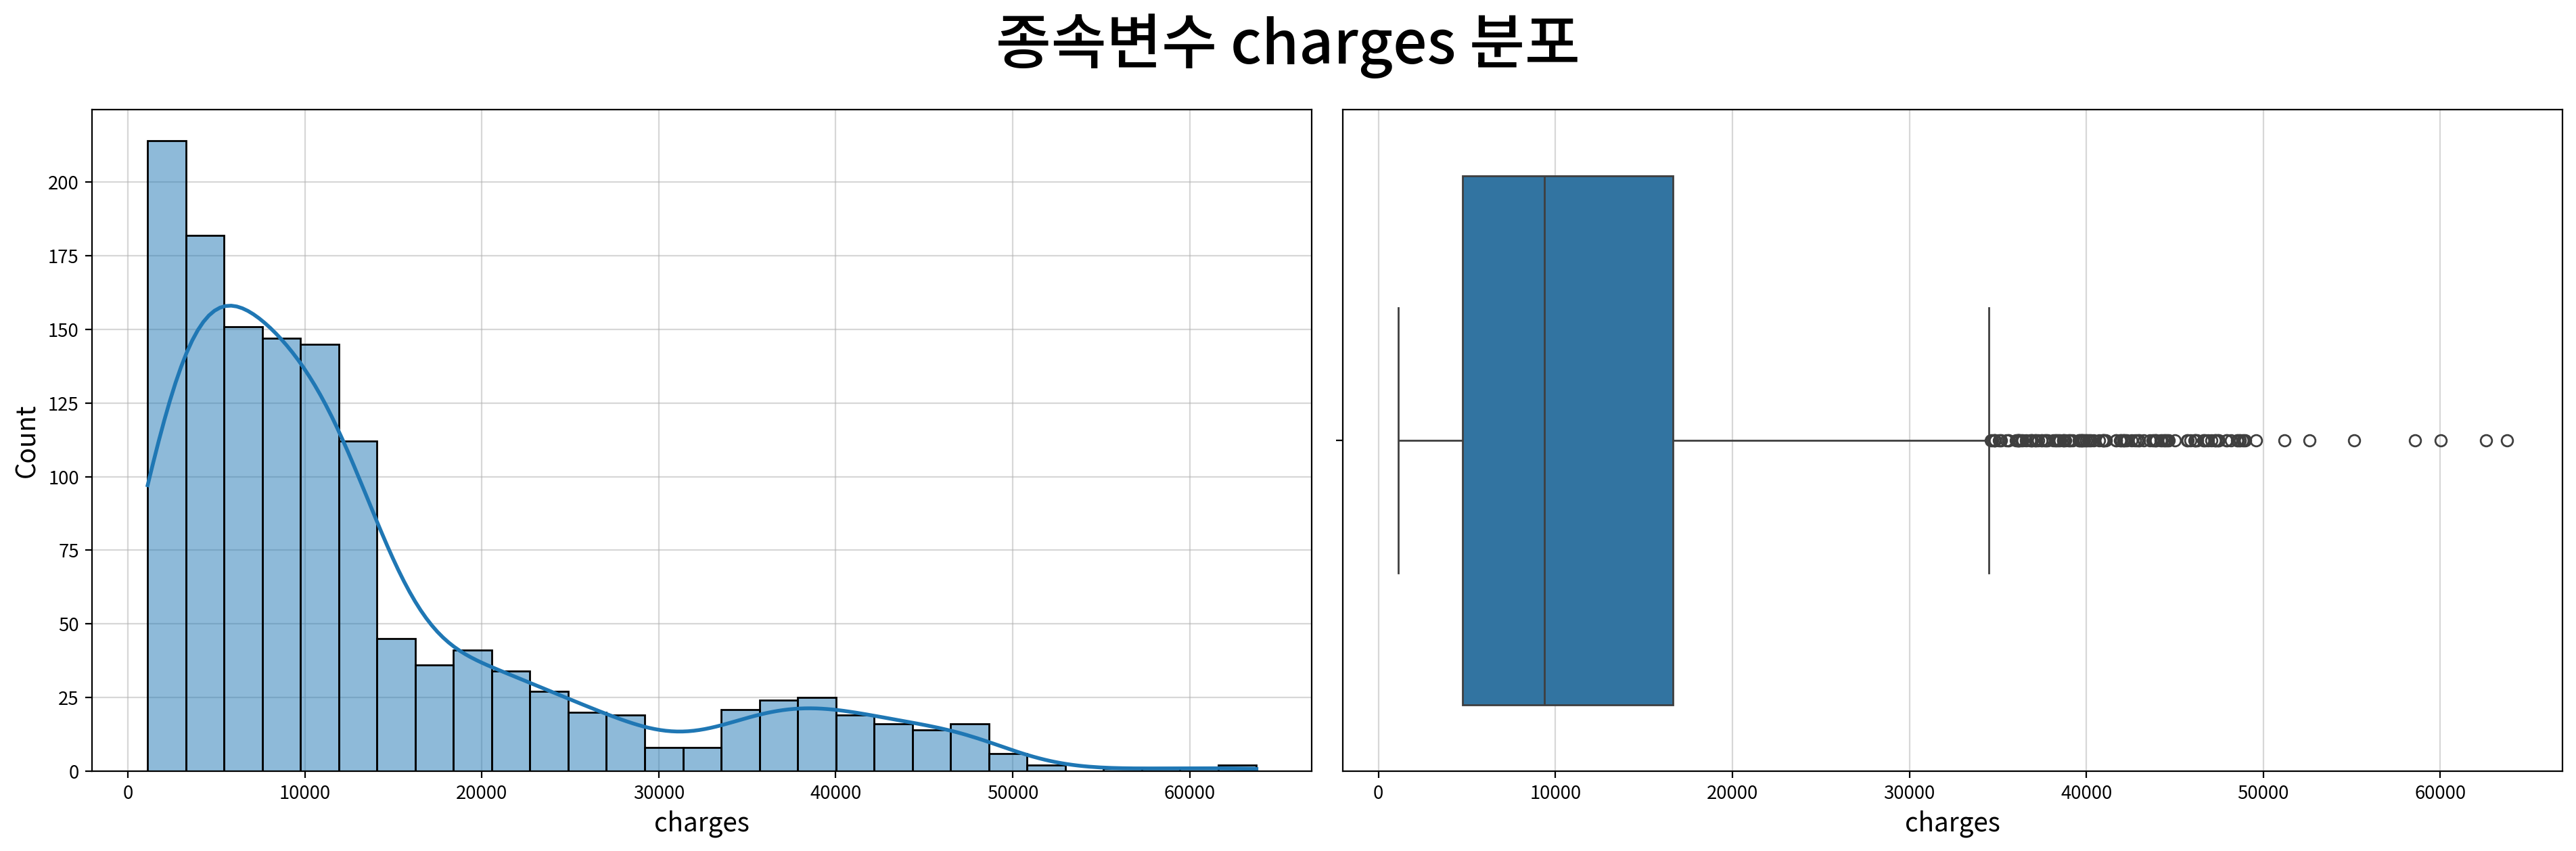

,charges
count,1337.000
mean,13279.121
std,12110.360
min,1121.874
25%,4746.344
50%,9386.161
75%,16657.717
max,63770.428
rel_diff,0.415
rdiff_flag,diff


In [41]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
desc[desc.index == target].T

#### 청구비용 분포 해석

charges는 중앙값 9,386.161달러보다 평균 13,279.121달러가 높고 왜도도 1.515로 양수였다. 약 10.4%의 관측치가 상단 IQR 경계 밖에 있어 높은 청구비용이 오른쪽 꼬리를 형성했다. 비용을 대표하는 단일 숫자로 평균만 제시하면 분포 중심과 고액 관측치의 차이를 놓칠 수 있다.

양수인 charges에 log를 적용한 모형을 비교했지만 고액값이라는 이유로 종속변수를 삭제·대체하지 않았다. 최종 성능표에서는 로그변환의 분포 개선과 달러 단위 오차 개선이 일치하지 않았다. 따라서 분포 모양만으로 최종 모형을 선택하지 않는다.

### 독립변수의 단변량 분석

#### 1. 연속형 독립변수

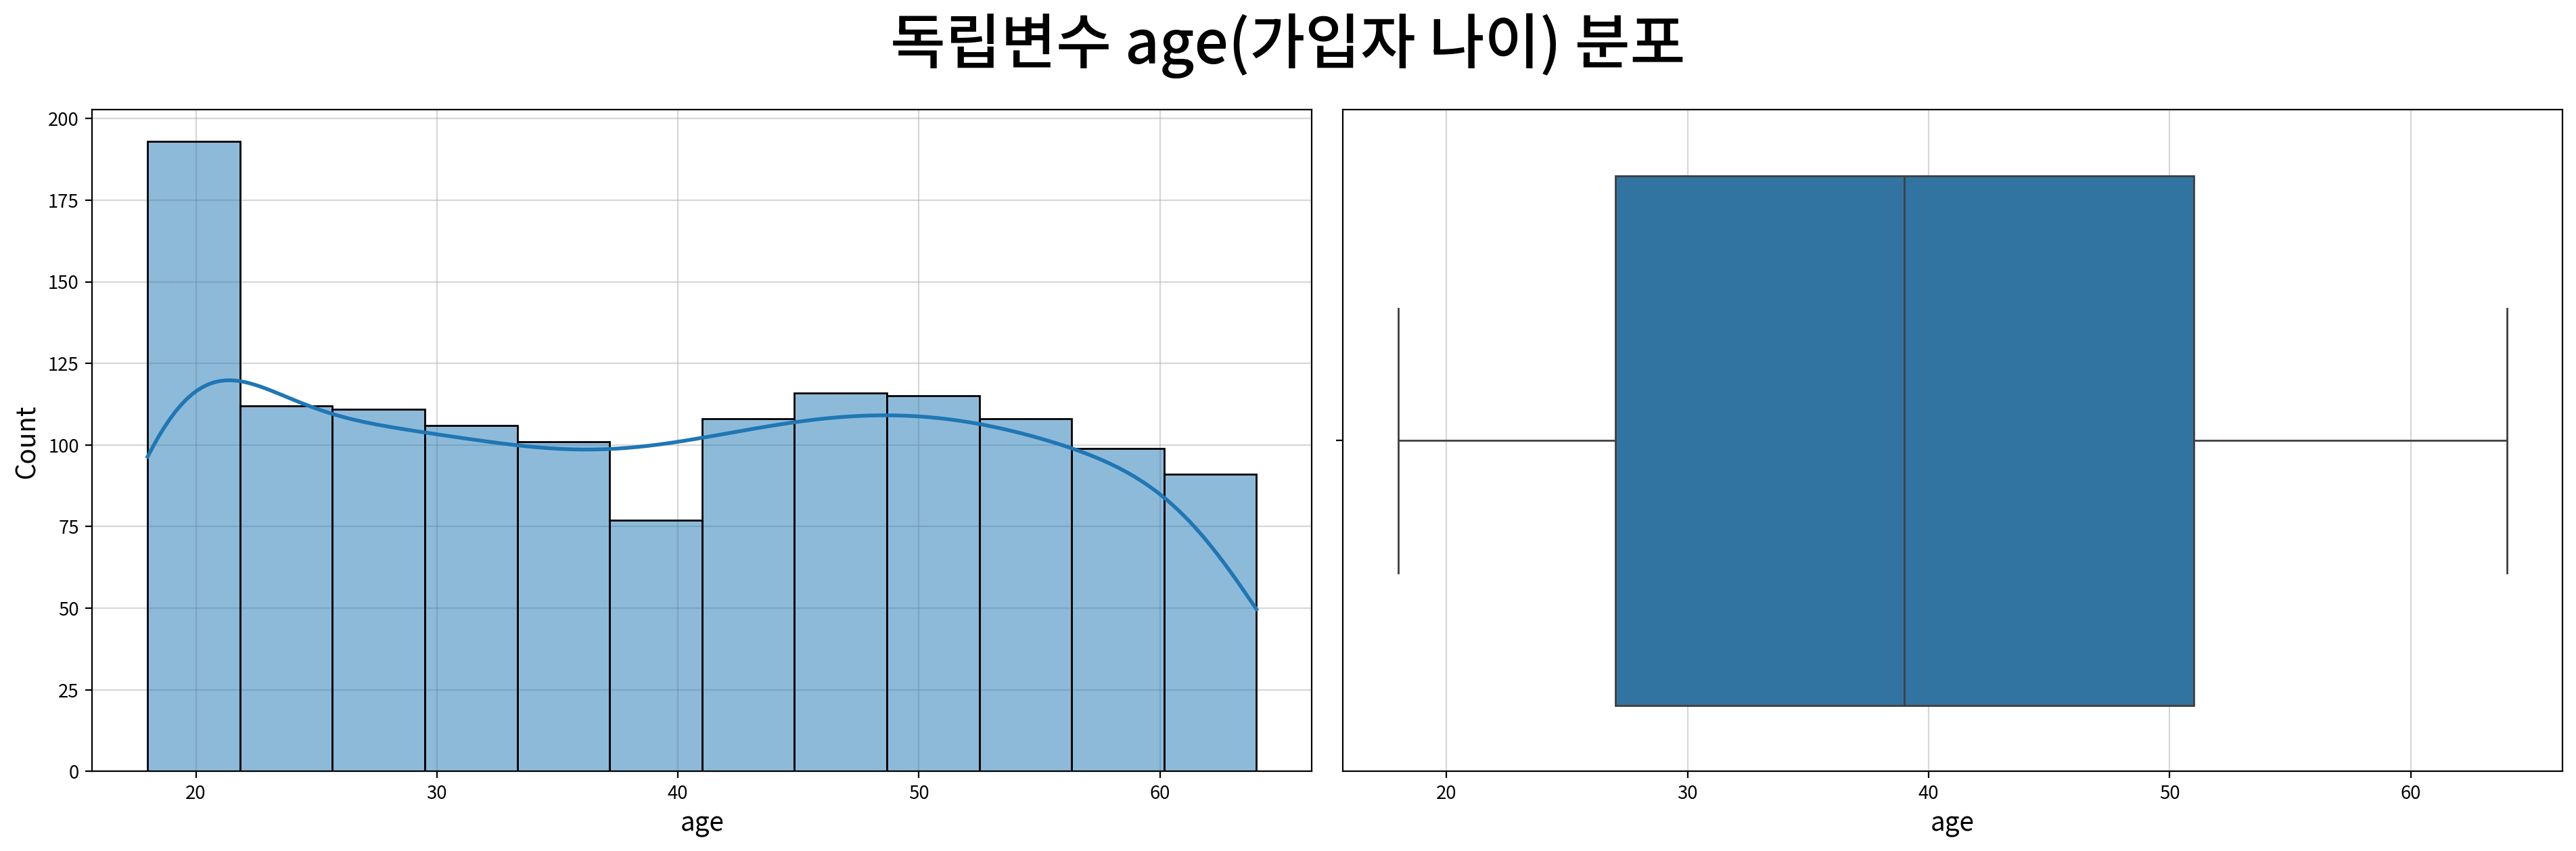

,age
count,1337.000
mean,39.222
std,14.044
min,18.000
25%,27.000
50%,39.000
75%,51.000
max,64.000
rel_diff,0.006
rdiff_flag,similar


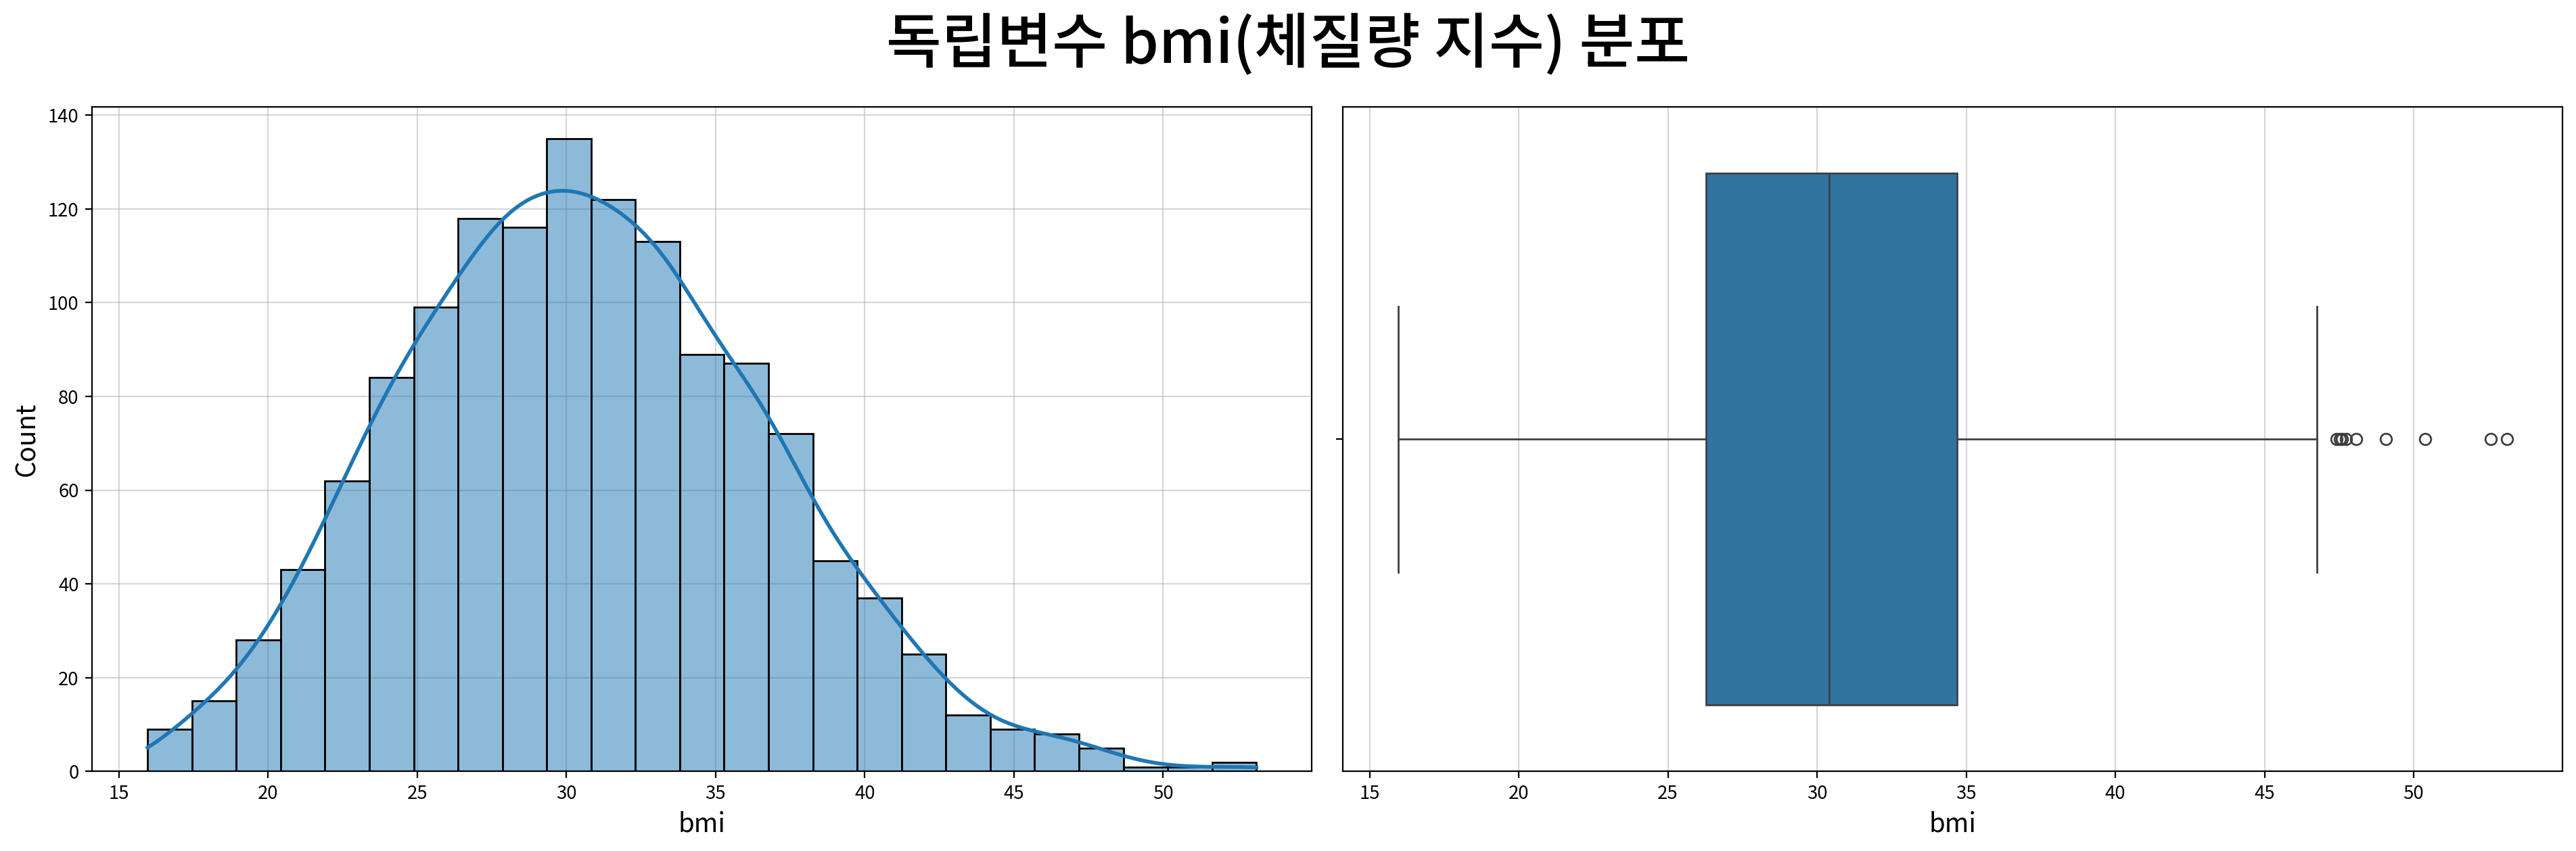

,bmi
count,1337.000
mean,30.663
std,6.100
min,15.960
25%,26.290
50%,30.400
75%,34.700
max,53.130
rel_diff,0.009
rdiff_flag,similar


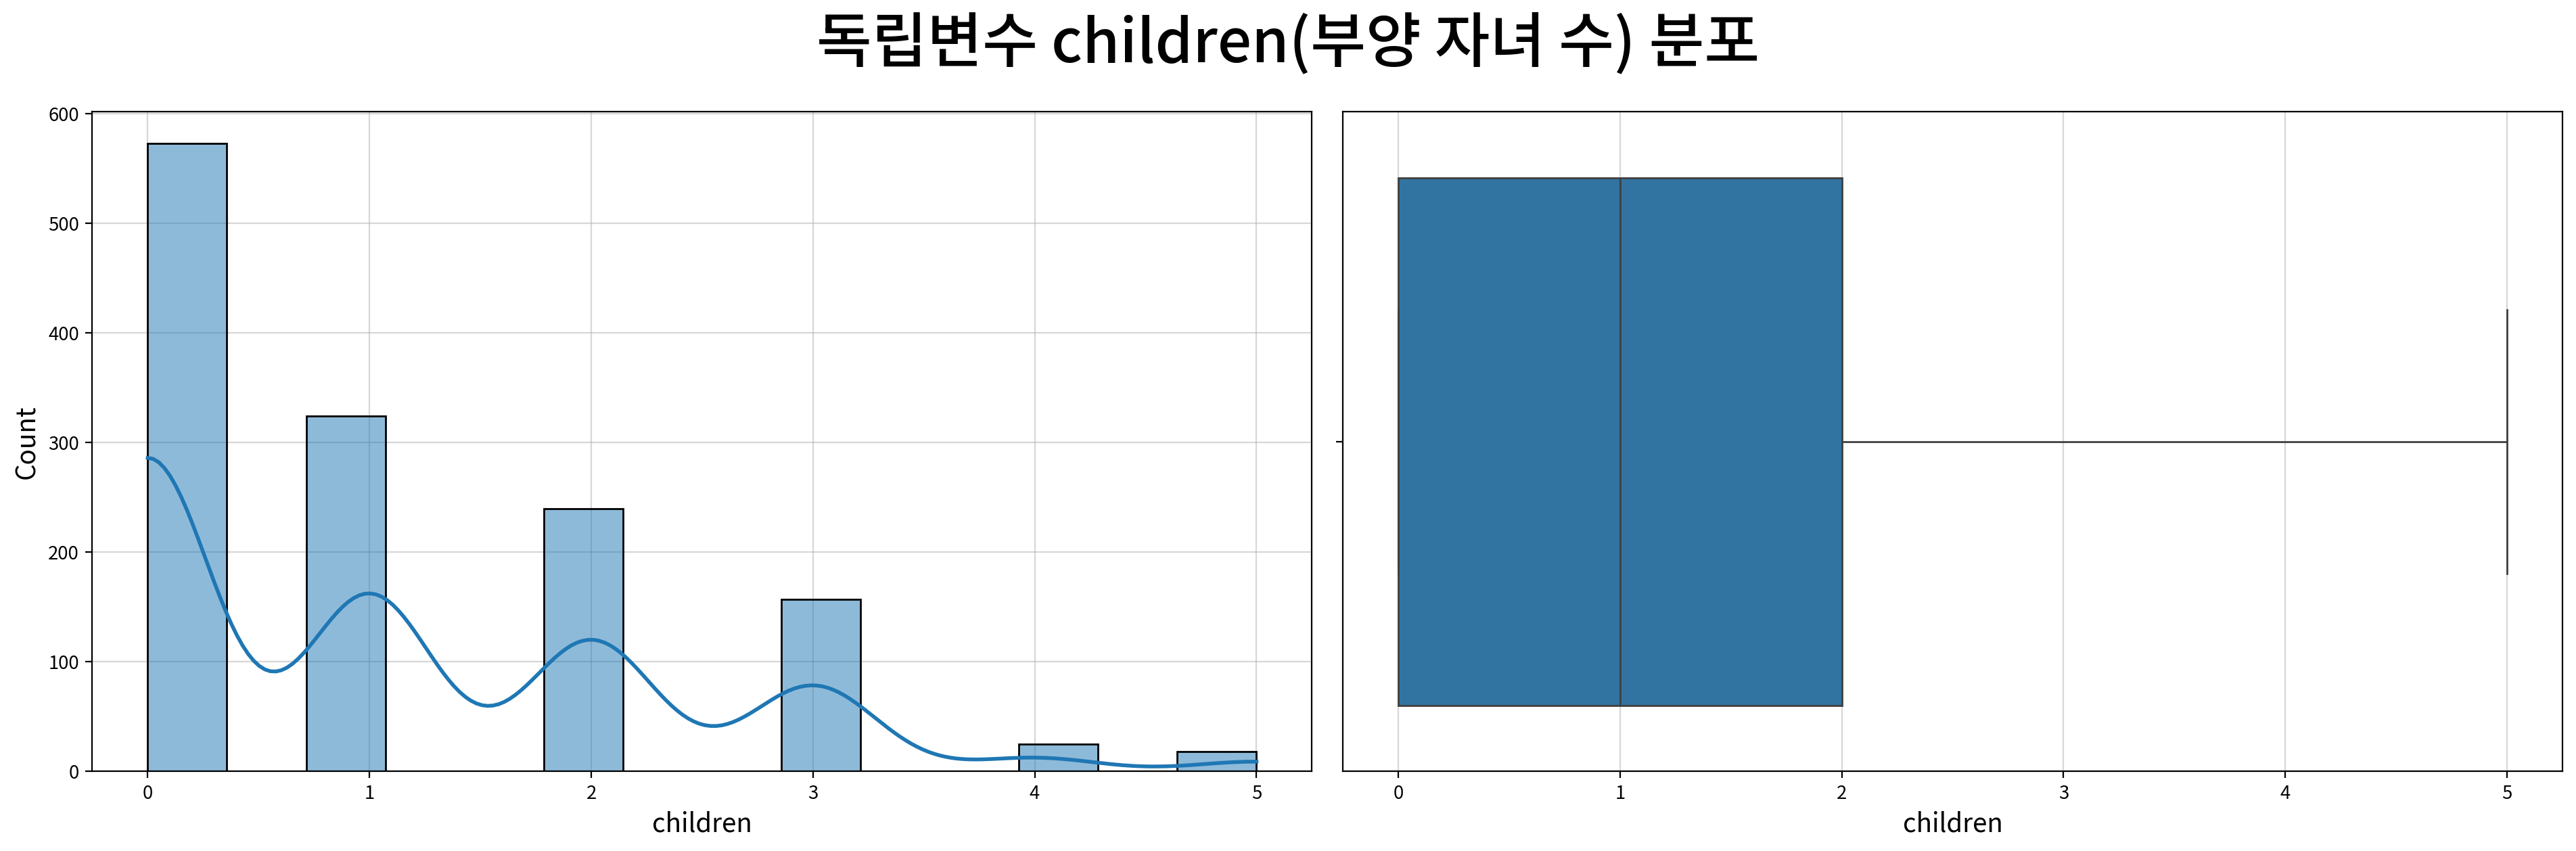

,children
count,1337.000
mean,1.096
std,1.206
min,0.000
25%,0.000
50%,1.000
75%,2.000
max,5.000
rel_diff,0.096
rdiff_flag,similar


In [42]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(desc[desc.index == f].T)

#### 연속형 독립변수 해석

age는 평균 39.222세, 중앙값 39세로 중심 차이가 작았고 IQR 이상치는 없었다. bmi는 평균 30.663, 중앙값 30.400, 왜도 0.284로 상대적으로 대칭에 가까웠지만 상단 이상치 9개가 있었다. children은 0~5의 개수 변수이며 왜도 0.937로 오른쪽 치우침이 있었다.

이런 분포 차이 때문에 모든 독립변수에 일괄 로그변환을 적용하지 않았다. 원본 요약표의 기준대로 children에만 log1p를 적용한 체크포인트를 비교했다. 독립변수가 대칭적으로 보인다는 사실은 회귀 잔차의 정규성이나 선형성을 보장하지 않으므로, 관계 검정과 최종 잔차 진단은 별도로 수행했다.

#### 2. 명목형 독립변수

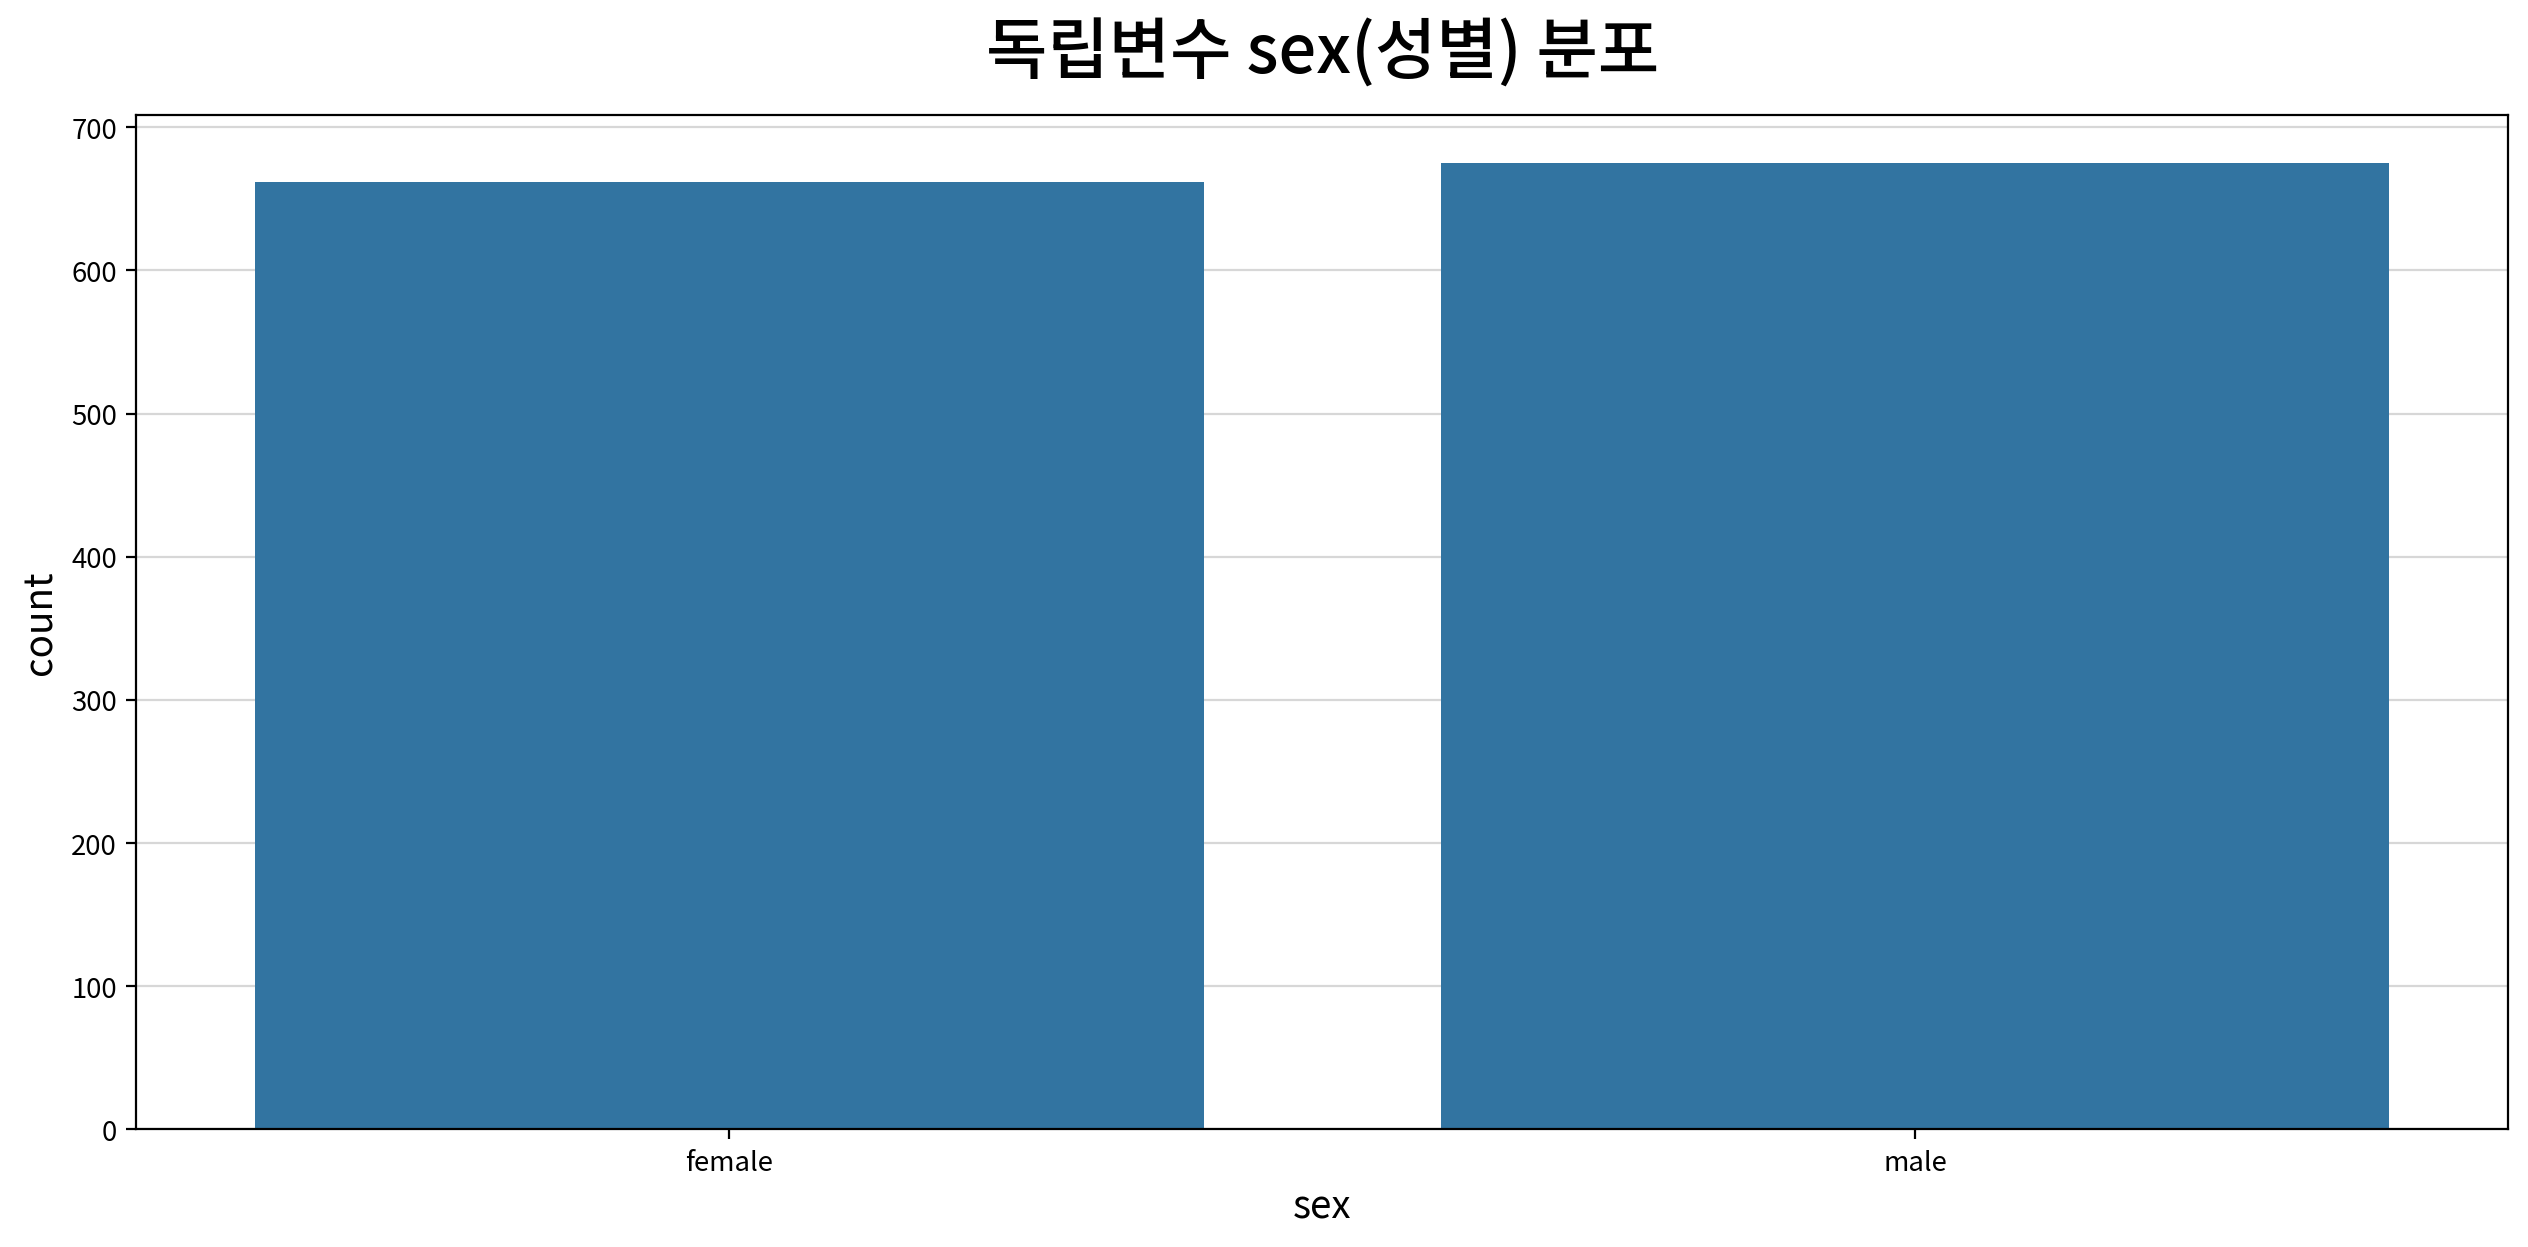

,count,unique,top,freq
sex,1337,2,male,675


,빈도,비율
sex,,
male,675,0.505
female,662,0.495


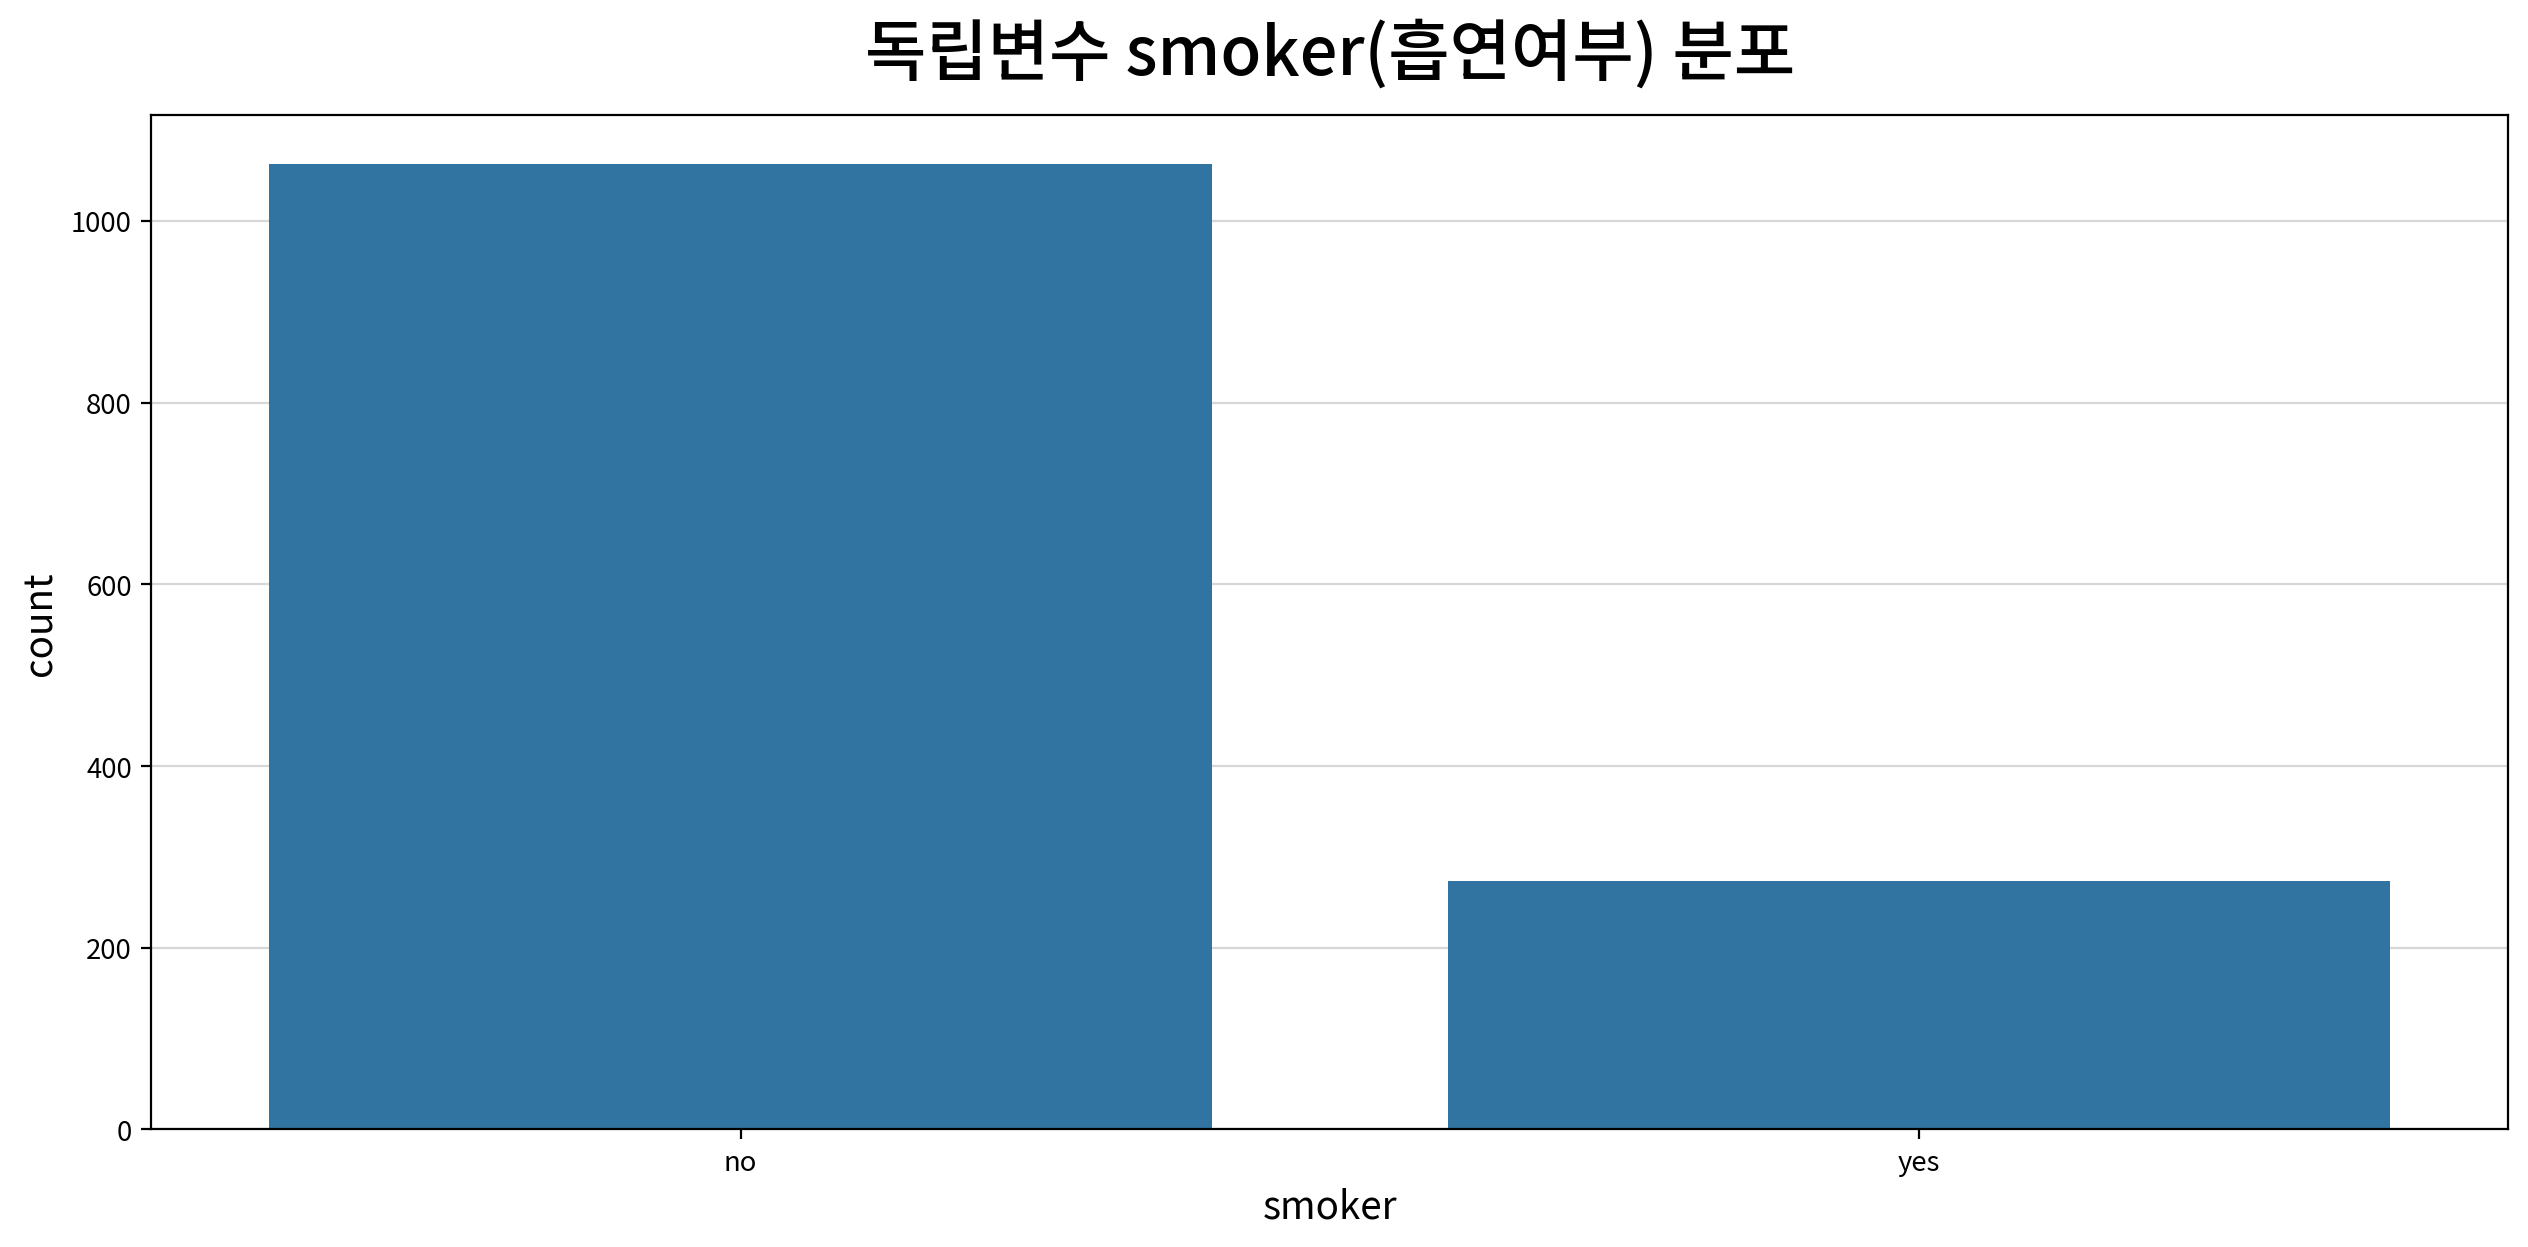

,count,unique,top,freq
smoker,1337,2,no,1063


,빈도,비율
smoker,,
no,1063,0.795
yes,274,0.205


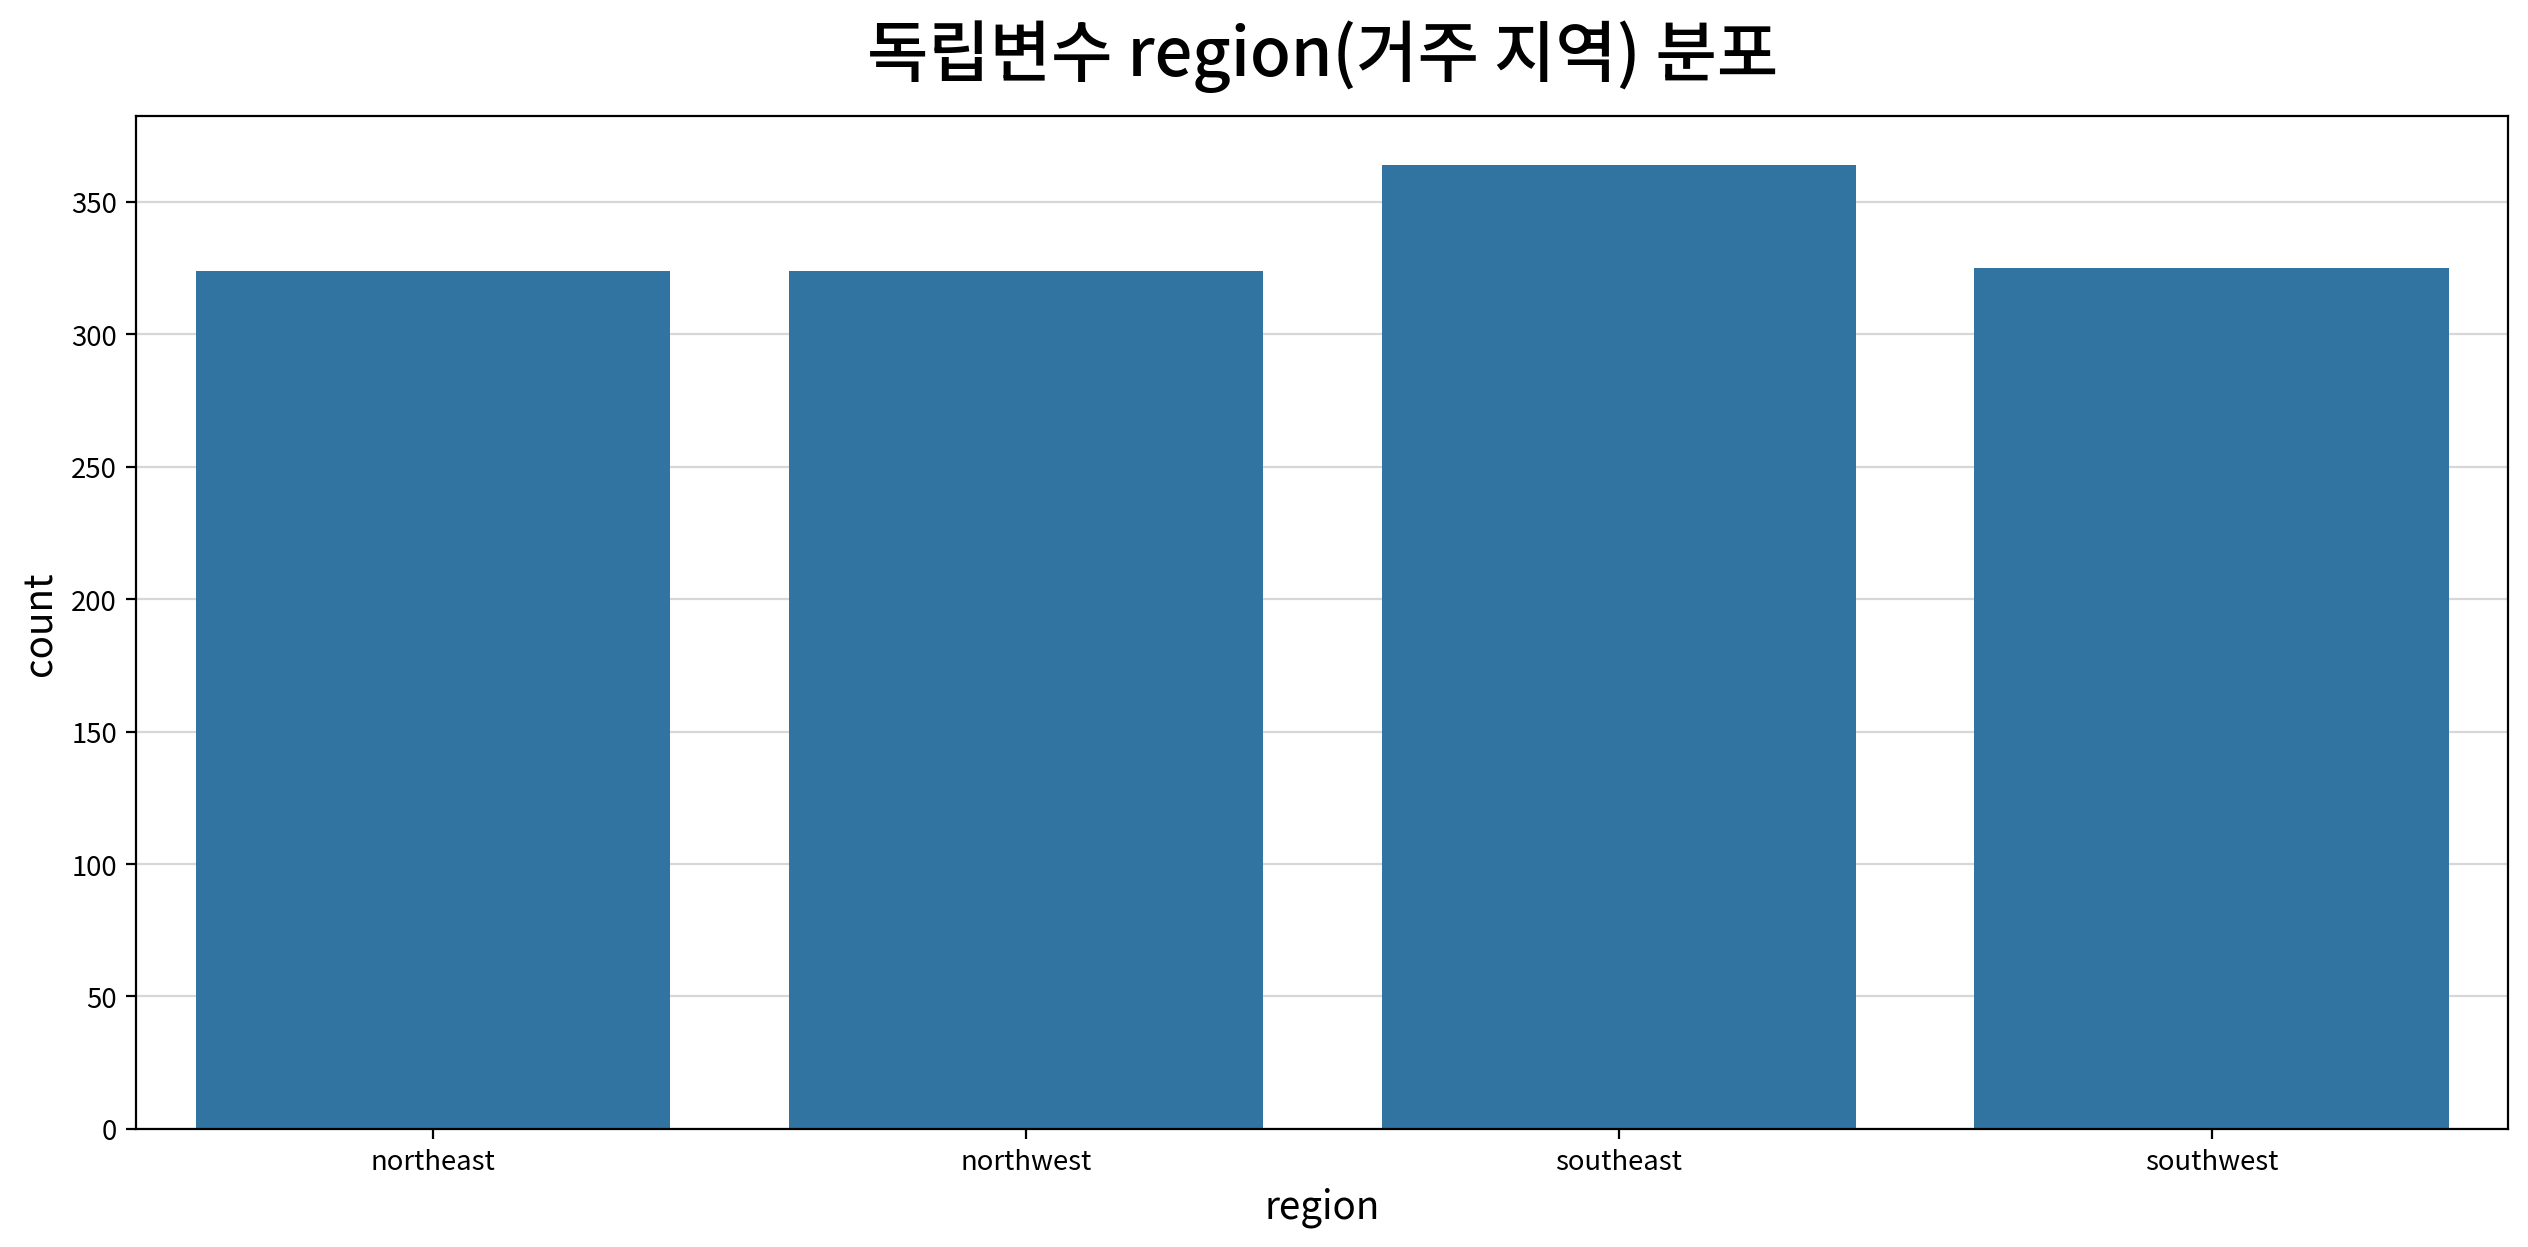

,count,unique,top,freq
region,1337,4,southeast,364


,빈도,비율
region,,
southeast,364,0.272
southwest,325,0.243
northwest,324,0.242
northeast,324,0.242


In [43]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### 범주 구성과 해석 범위

sex는 남성 675명·여성 662명으로 비슷한 규모였다. smoker는 비흡연자 1,063명(약 79.5%), 흡연자 274명(약 20.5%)으로 불균형했다. region은 southeast 364명, southwest 325명, northwest·northeast 각 324명이었다.

흡연 여부의 범주 비율과 비용 차이는 별개다. 빈도만으로 검정력이 충분하다고 단정하지 않고 실제 분포와 검정 결과를 확인했다. sex·smoker에는 가정 점검 후 Mann–Whitney U 검정이, region에는 Welch ANOVA와 Games–Howell 사후검정이 적용됐다.

<a id="bivariate"></a>

## 2-2. 이변량 분석

### 준비작업

### 앞 절의 분석 설정 재사용

동일 노트북 앞 절에서 불러온 데이터와 변수 유형 설정을 사용한다.

#### 2. 불러온 내용 확인

- 이전 분석 내역이 잘 로드 되었는지 확인한다.

In [44]:
print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형   :", continuous_cols)
print("명목형   :", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수 : charges
종속변수 유형: 연속형
연속형   : ['age', 'bmi', 'children']
명목형   : ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


#### 3. 라이브러리 참조

- display는 ipynb에서 사용할 수 있는 전용 출력 함수
- Markdown은 ipynb의 출력 내용에 마크다운을 사용할 수 있게 한다.

In [45]:
from IPython.display import display, Markdown

#### 이전 분석 과정에서 설계한 검정 후보

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                        | 적용 여부 | 비고                |
|-----------|-----------|-------|------------------------------|-------|-------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 3종 → charges        | ✅ 적용  | 종속·설명 모두 연속형      |
| 연속형       | 명목형(2집단)  | Mann–Whitney U   | sex, smoker → charges        | ✅ 적용  | sex, smoker가 이진변수 |
| 연속형       | 명목형(3집단+) | ANOVA | region → charges             | ✅ 적용  | region이 4집단       |
| 명목형(2집단)  | 연속형       | T검정   | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(2집단)  | 명목형(2집단)  | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(2집단)  | 명목형(3집단+) | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 연속형       | ANOVA | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 명목형(2집단)  | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |

### 이변량 분석

#### 1. 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶︎ age(가입자 나이) → charges

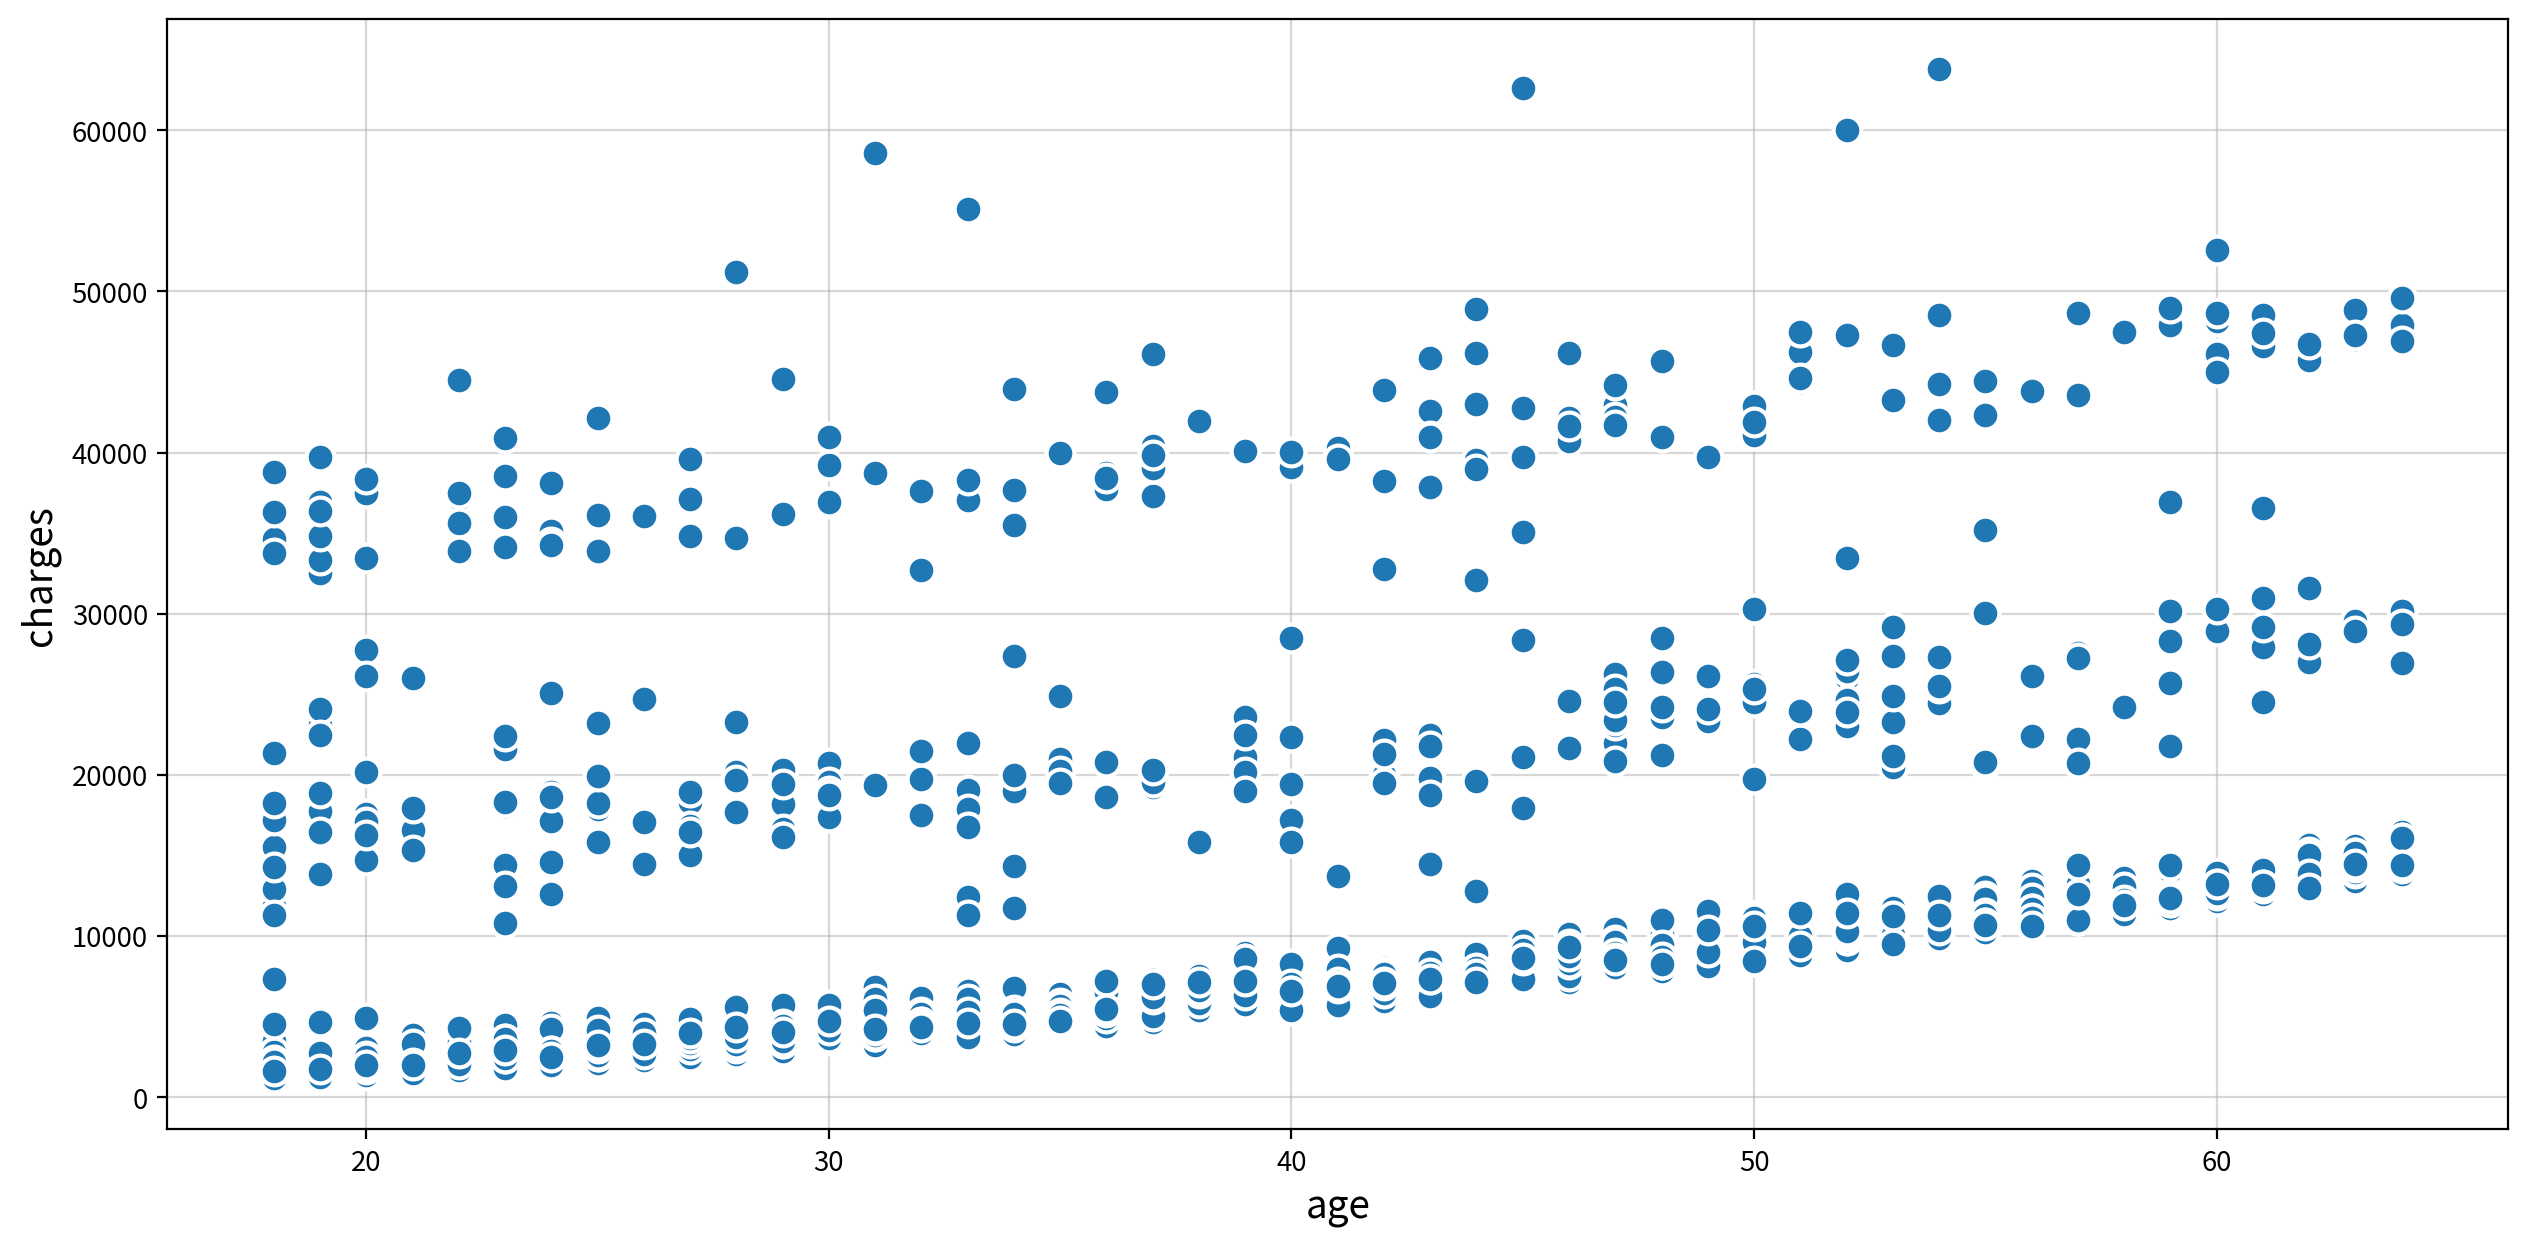

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
age,charges,Spearman,0.533,0.000,Moderate,True,False,False,True,True,True


#### ▶︎ bmi(체질량 지수) → charges

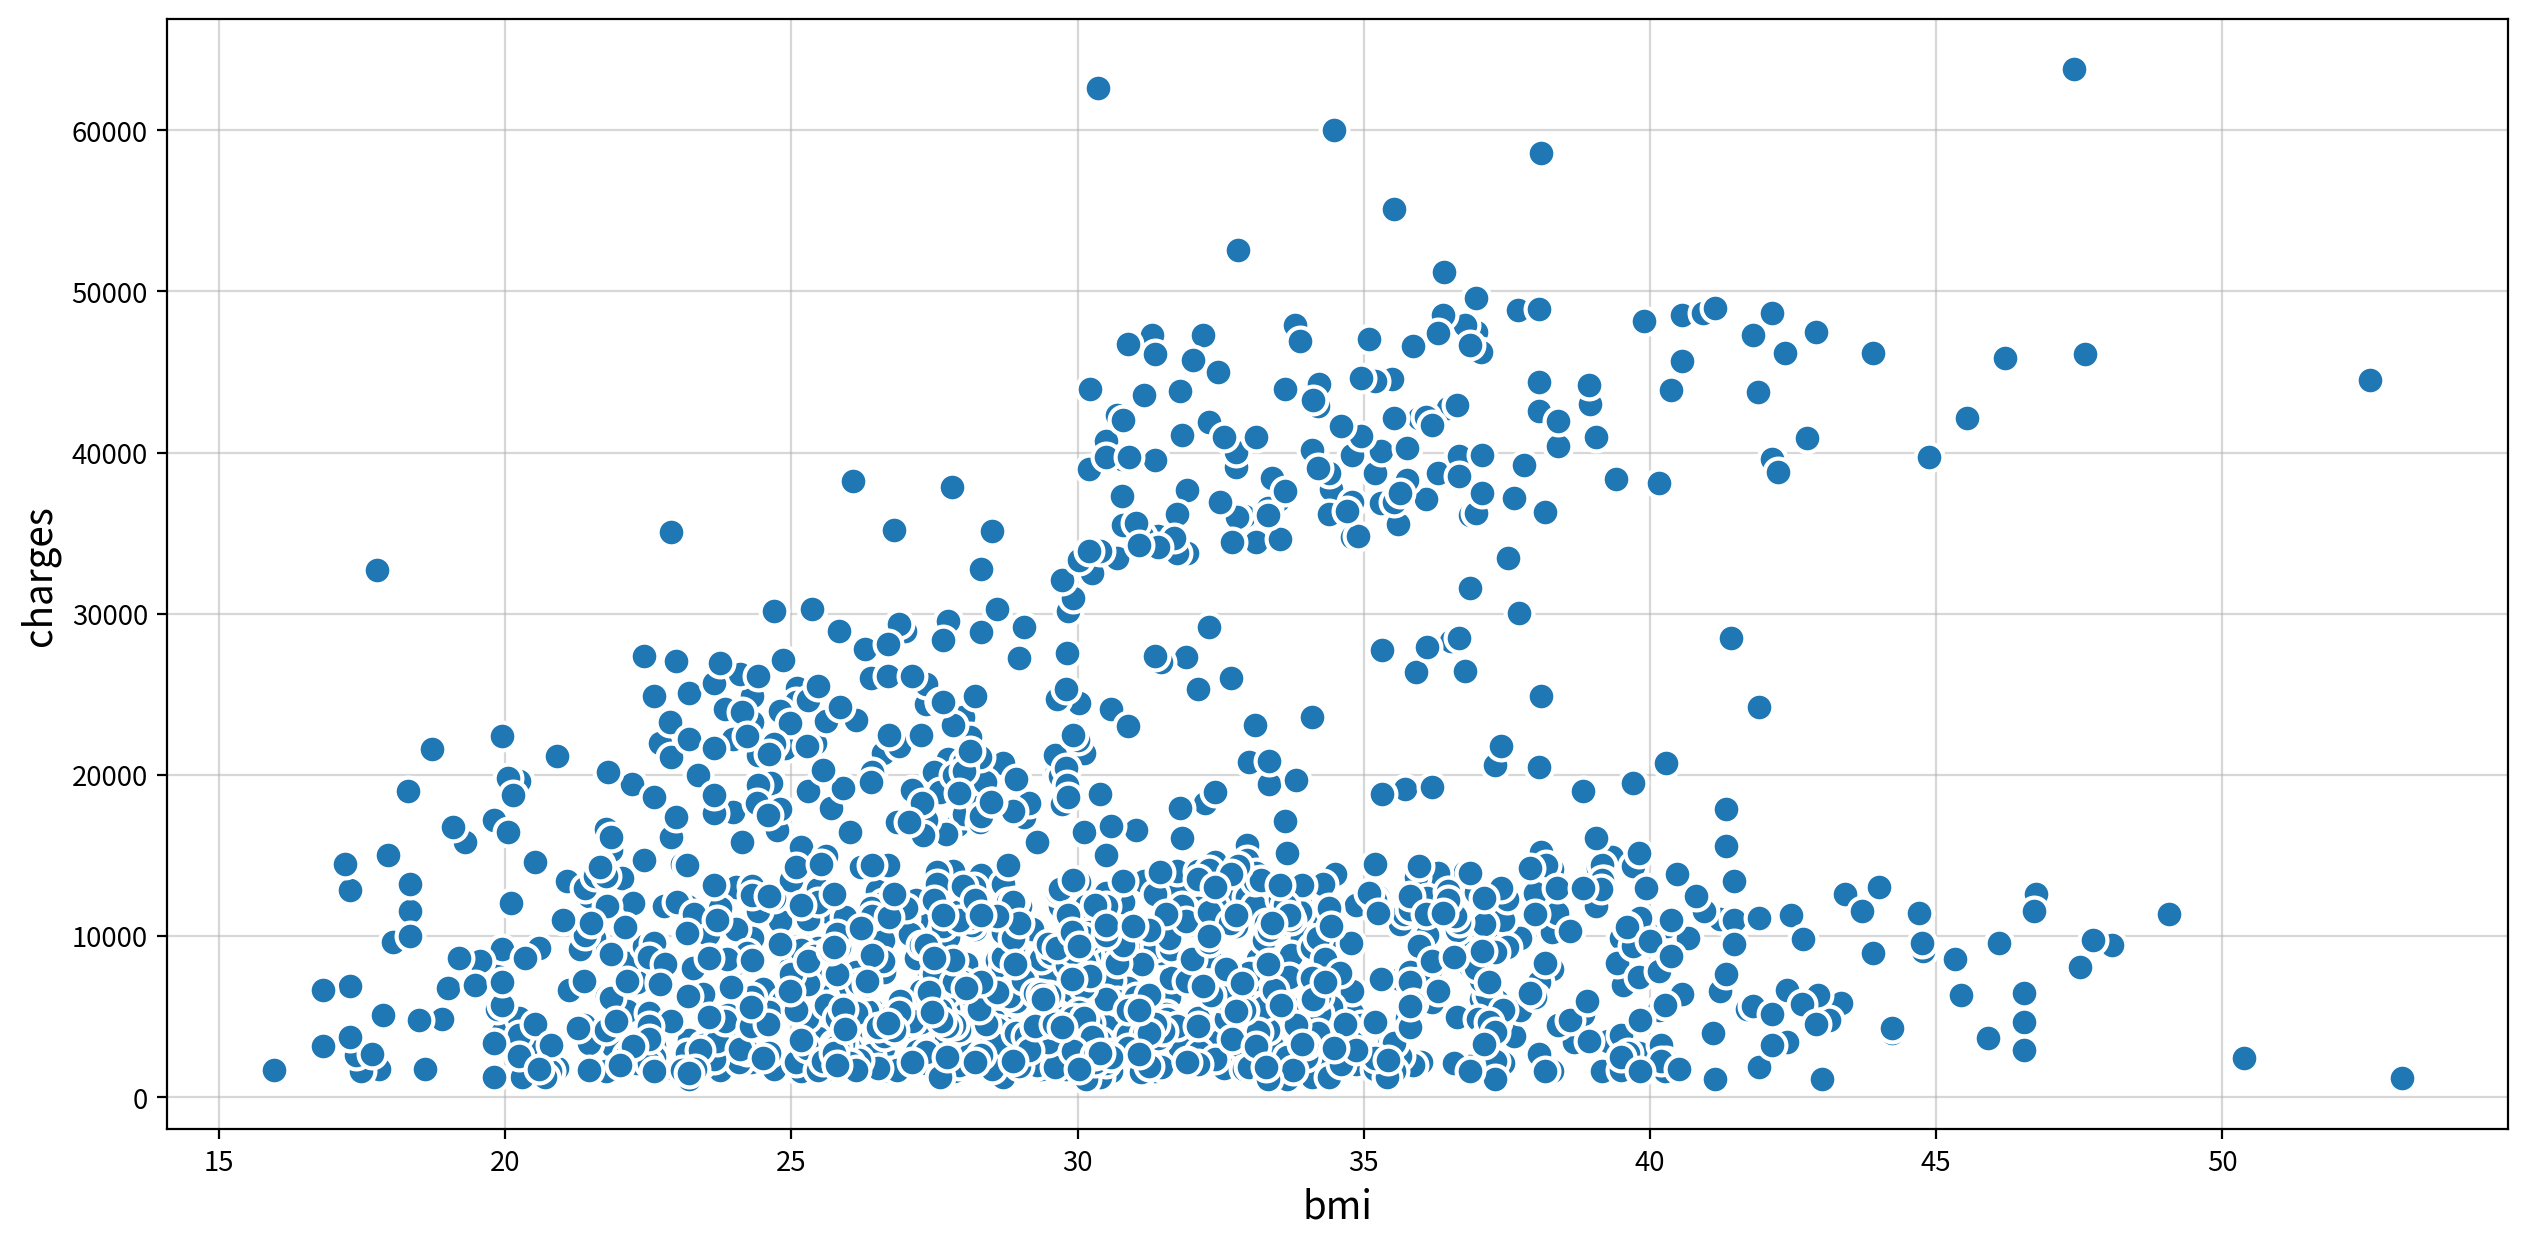

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bmi,charges,Spearman,0.120,0.000,Weak,True,False,False,True,True,True


#### ▶︎ children(부양 자녀 수) → charges

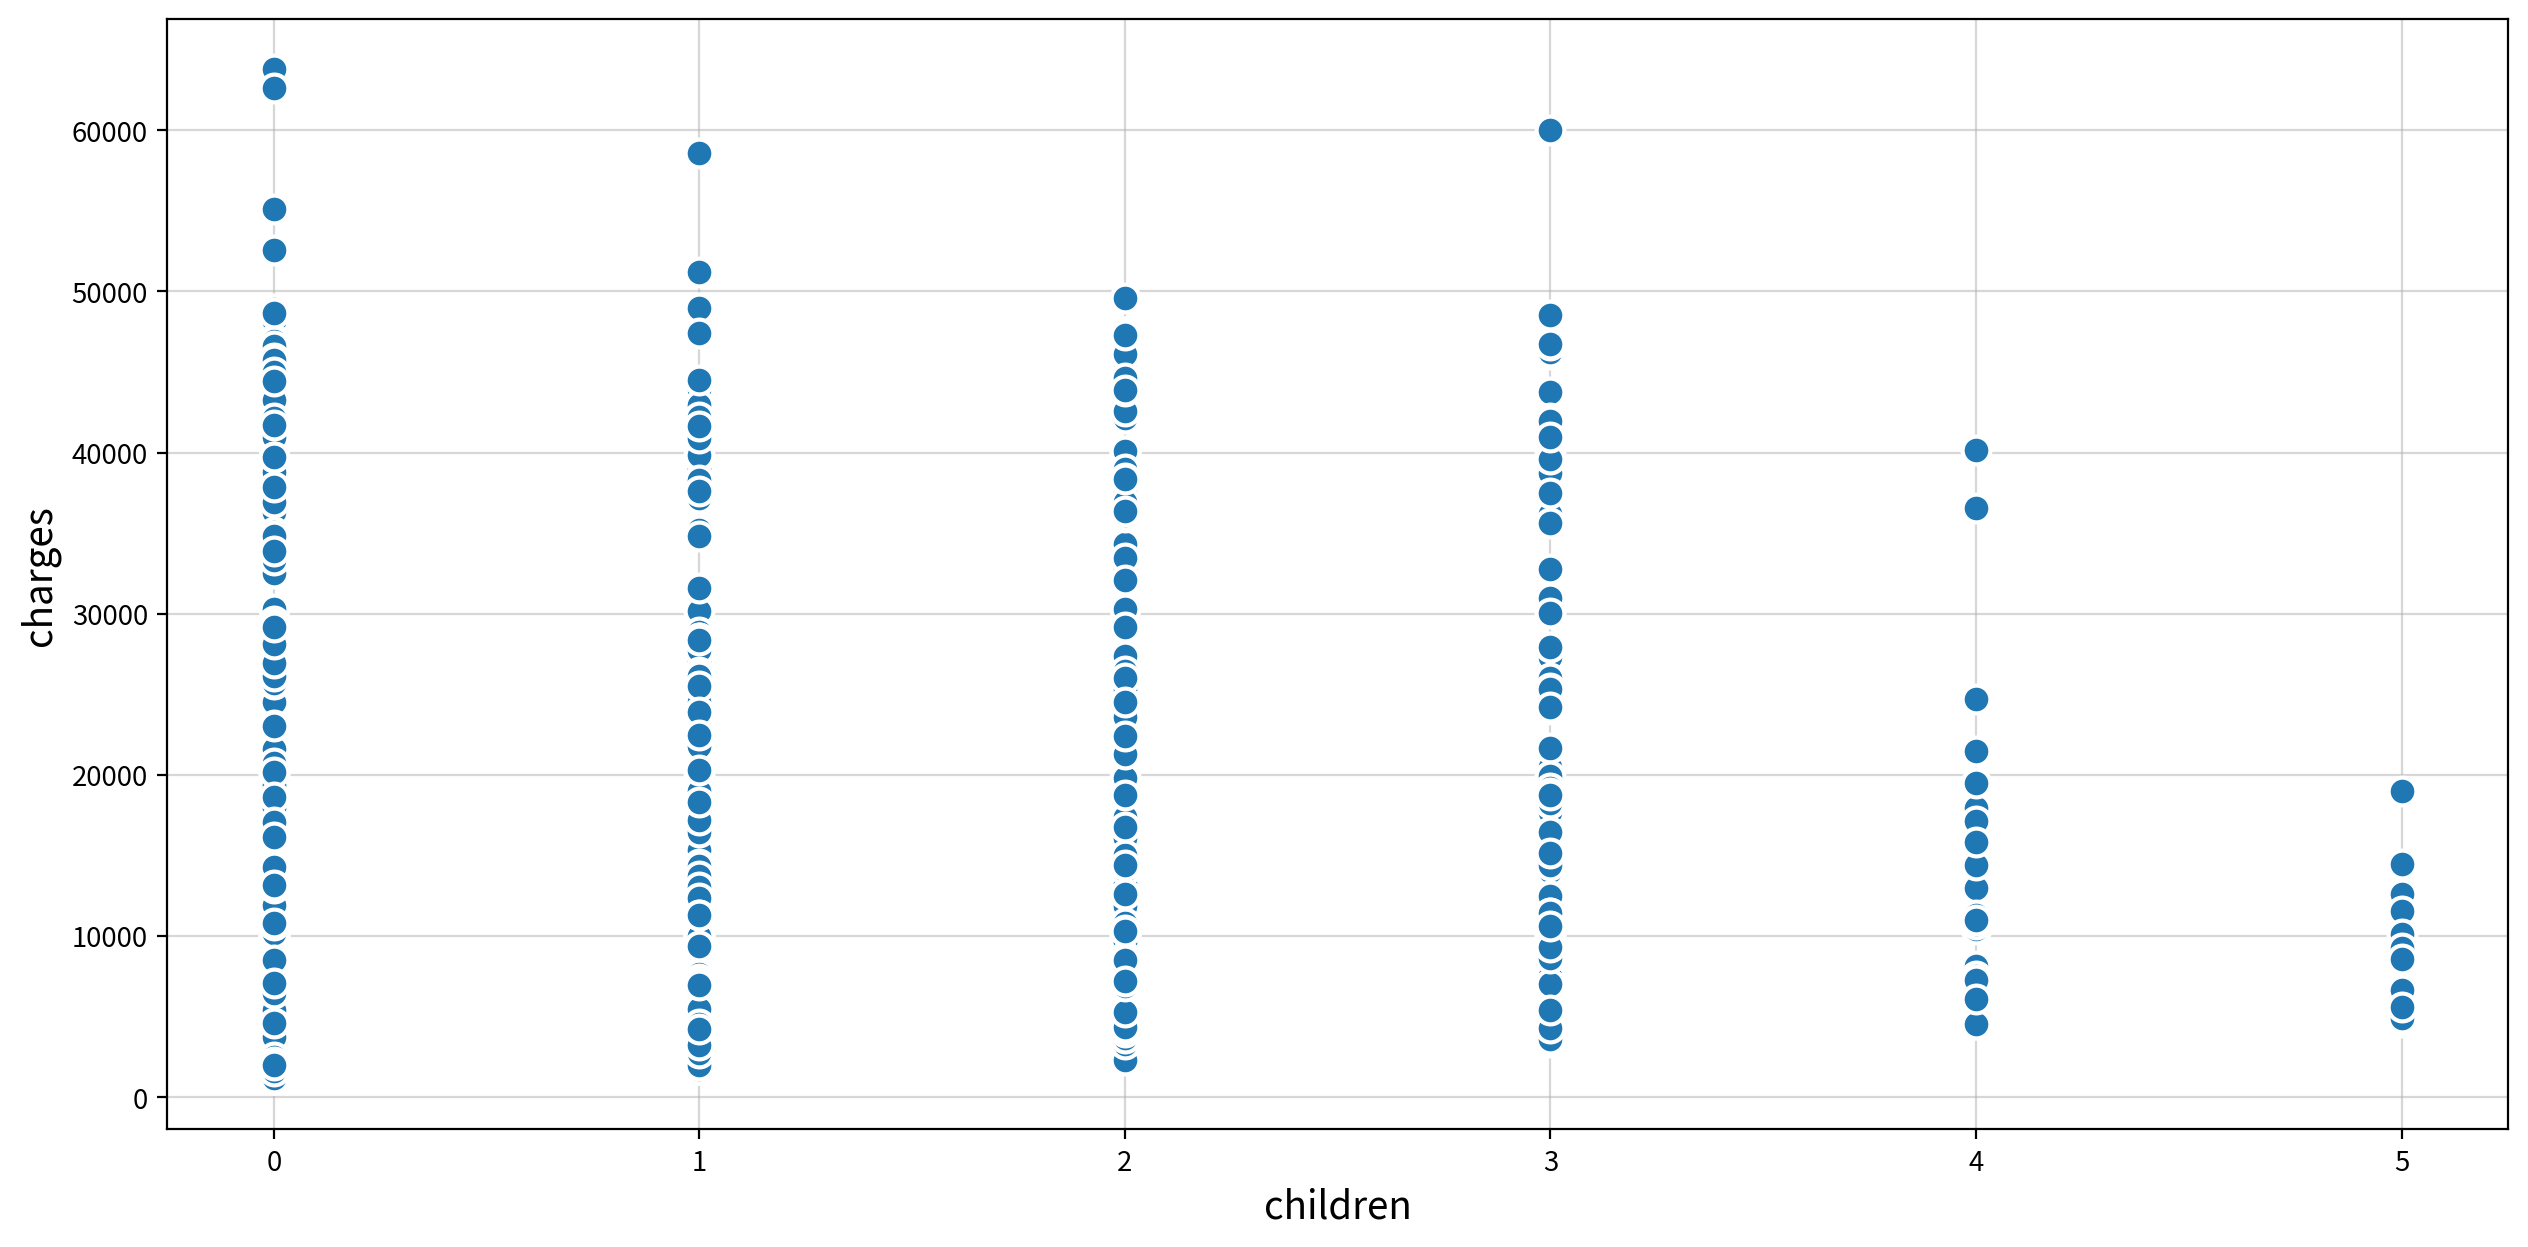

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
children,charges,Spearman,0.132,0.000,Weak,True,False,False,False,False,True


In [46]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target))

##### 결과 해석 (그래프별 정리)

**`age` → `charges`** — 가입자 나이

| 확인 항목 | 관찰 내용 |
|---|---|
| 선형/비선형 | `linearity=True` → **선형성 검정에서 기각되지 않음** |
| 단조성 | ρ=+0.533 → age↑ → charges↑ 양의 단조 증가 |
| 산포 | `normality_x=False`, `normality_y=False` → 두 변수 모두 정규성 미충족 → **Spearman 자동 선택** |
| 이상치 | `influential_outlier=True` → 계수를 왜곡할 수 있는 영향점 존재 |
| **채택 여부** | **채택** — 유의한 양의 중간 상관(Spearman ρ=0.533, Moderate, p<0.05) |

**`bmi` → `charges`** — 체질량 지수

| 확인 항목 | 관찰 내용 |
|---|---|
| 선형/비선형 | `linearity=True` → **선형성 검정에서 기각되지 않음** |
| 단조성 | ρ=+0.120 → bmi↑ → charges↑ 방향이나 매우 약함 |
| 산포 | `normality_x=False`, `normality_y=False` → 두 변수 모두 정규성 미충족 → **Spearman 자동 선택** |
| 이상치 | `influential_outlier=True` → 계수를 왜곡할 수 있는 영향점 존재 |
| **채택 여부** | **후보** — 유의하나 Spearman ρ=0.120(**Weak**, \|ρ\|<0.3)로 단독 설명력 미미 |

**`children` → `charges`** — 부양 자녀 수

| 확인 항목 | 관찰 내용 |
|---|---|
| 선형/비선형 | `linearity=False` → **선형성 미충족** |
| 단조성 | ρ=+0.132 → children↑ → charges↑ 방향이나 매우 약함 |
| 산포 | `normality_x=False`, `normality_y=False` → 두 변수 모두 정규성 미충족 → **Spearman 자동 선택** |
| 이상치 | `influential_outlier=False` → 계수를 왜곡하는 영향점 없음 |
| **채택 여부** | **후보** — 유의하나 Spearman ρ=0.132(**Weak**, \|ρ\|<0.3)로 단독 설명력 미미 |

> 유의하지 않은 차이는 동등성의 증명이 아니다. 이변량 관계나 쌍별 상관만으로 다변량 관계 전체를 확정하지 않는다.

#### 2. T-Test (x: 2집단 명목형 독립변수 → y: 종속변수)

- 명목형과 `charges`의 그룹 차이를 박스 플롯으로 확인한다

#### ▶︎ sex(성별) → charges

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

female vs. male: Mann-Whitney-Wilcoxon test two-sided, P_val:6.945e-01 U_stat=2.207e+05


C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


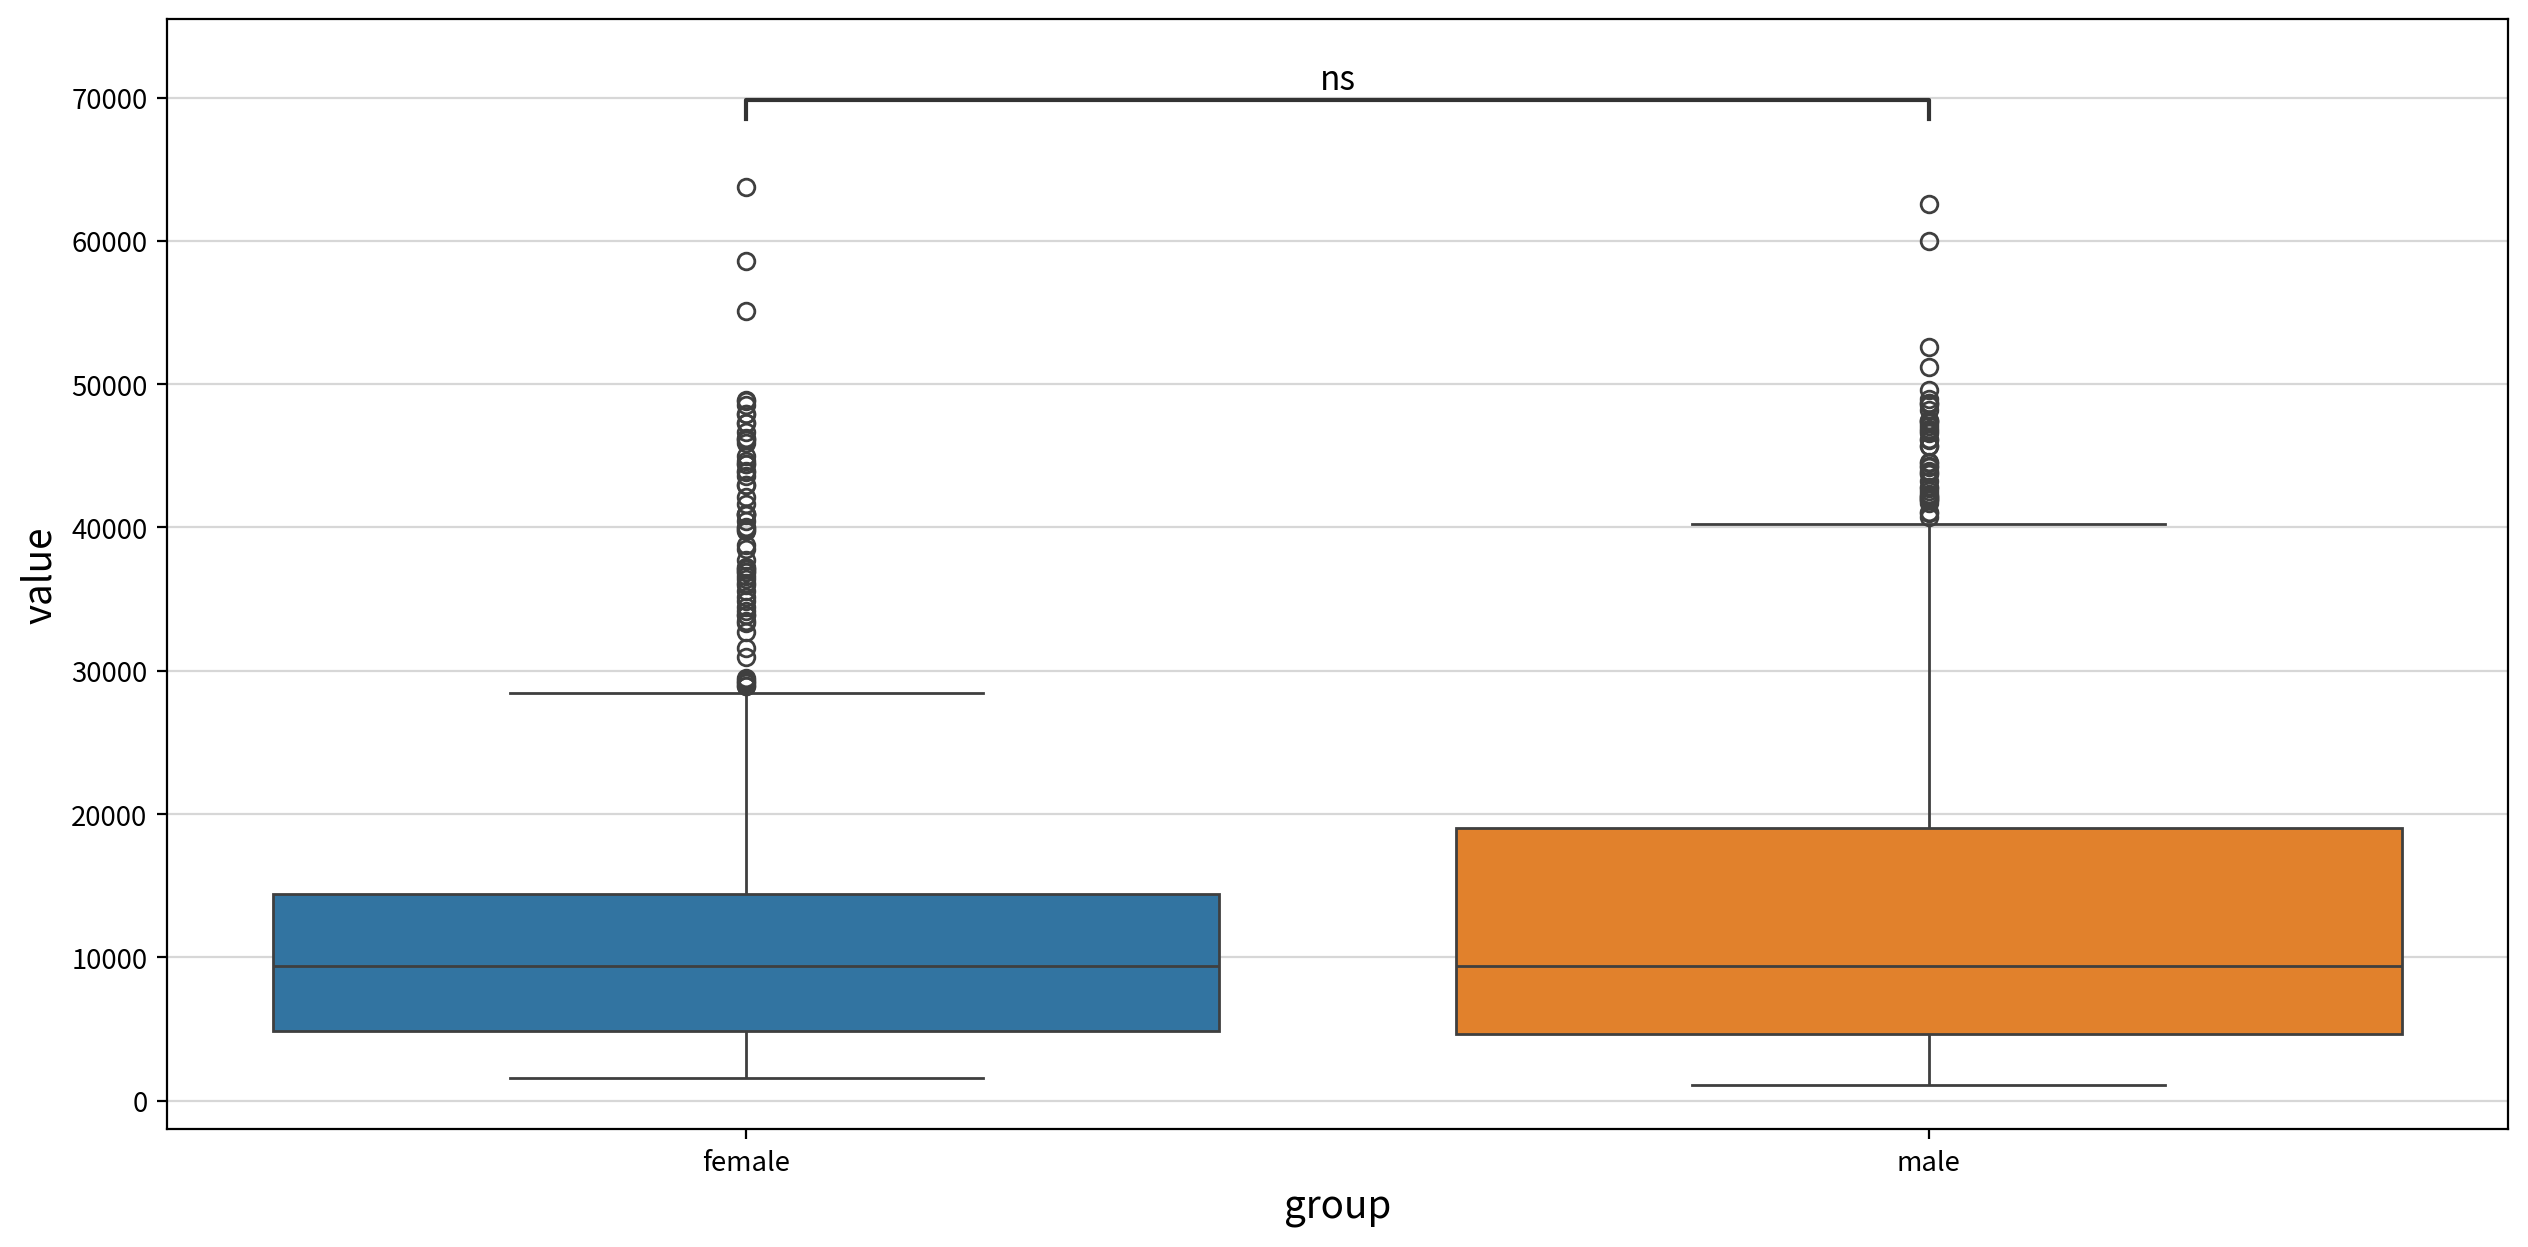

statistic  p-value  significant  \
test                alternative                                    
Mann-Whitney U test two-sided   220652.000    0.695        False   
                    less        220652.000    0.347        False   
                    greater     220652.000    0.653        False   

                                         result  
test                alternative                  
Mann-Whitney U test two-sided     female = male  
                    less         female >= male  
                    greater      female <= male

#### ▶︎ smoker(흡연여부) → charges

C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:5.747e-130 U_stat=7.403e+03


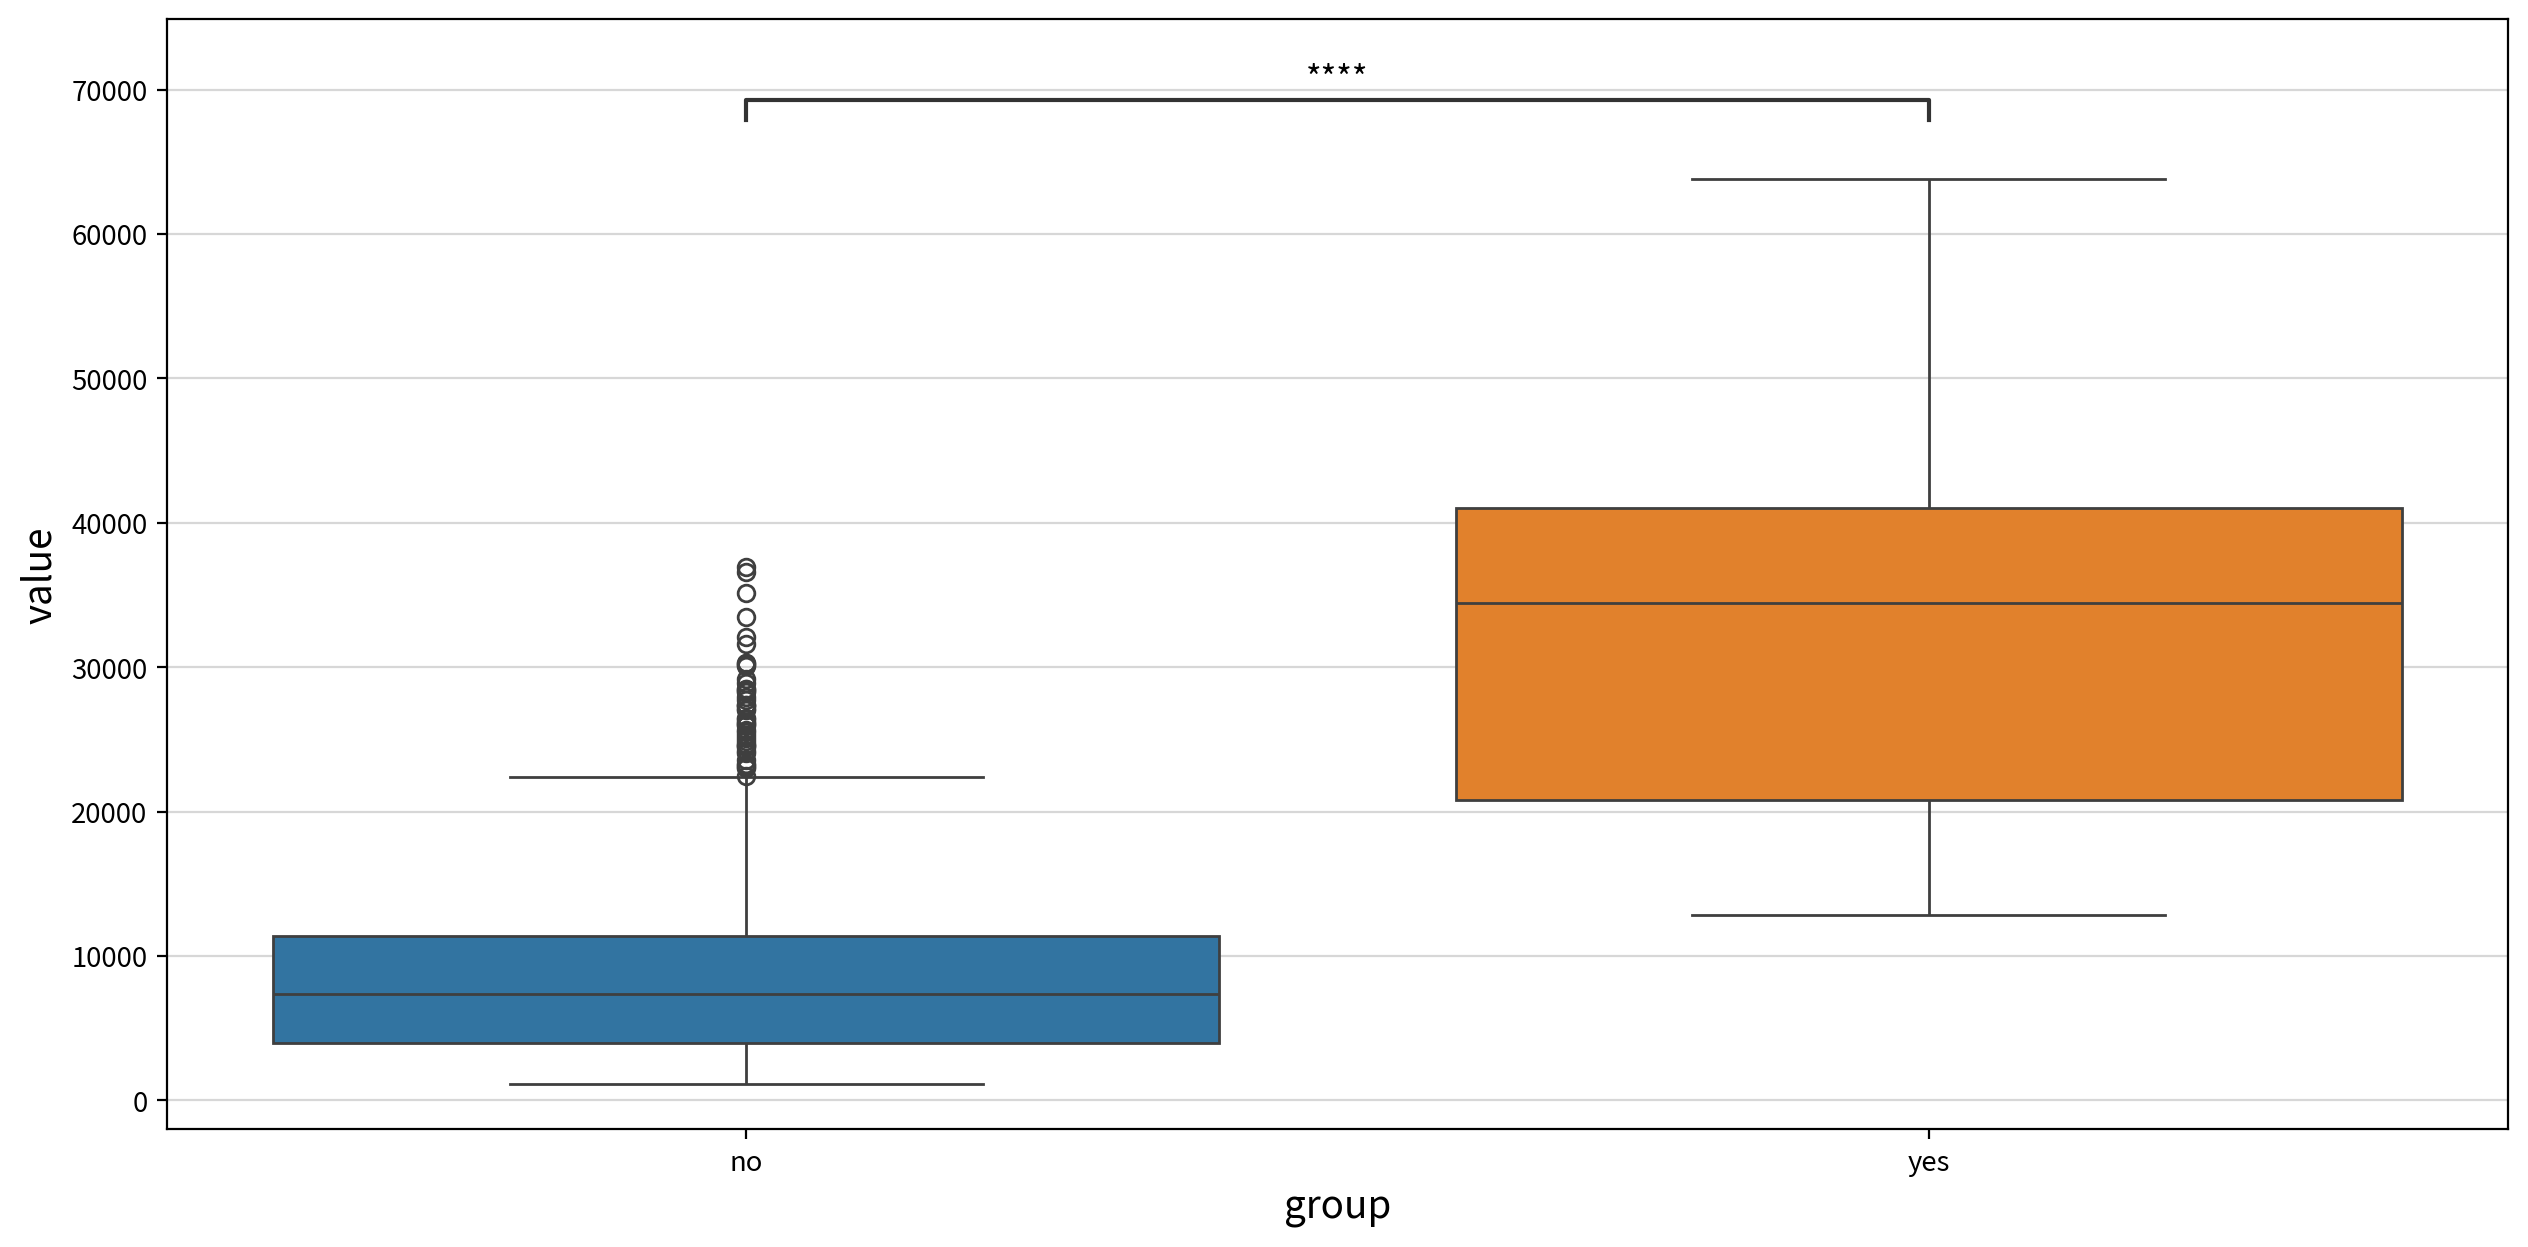

statistic  p-value  significant     result
test                alternative                                            
Mann-Whitney U test two-sided     7403.000    0.000         True  no != yes
                    less          7403.000    0.000         True   no < yes
                    greater       7403.000    1.000        False  no <= yes

In [47]:
for n in ['sex', 'smoker']:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    wide_df = my_prep.long2wide(origin, hue=n, values=target)
    display(my_stats.test_independent(wide_df, 
                group1=wide_df.columns[0], group2=wide_df.columns[1]))

#### 범주별 청구비용 차이 결과 해석

| 변수 | 실행 결과 | 해석 |
|---|---|---|
| sex | Mann–Whitney U 양측 p ≈ 0.695 | 유의한 차이를 발견하지 못했다. 여성과 남성의 비용이 같다는 증명은 아니다. |
| smoker | Mann–Whitney U 양측 p < 0.05 | 흡연자(yes) 쪽의 청구비용이 높은 방향이었다. 단측 대립가설의 방향은 실제 출력의 집단 순서와 함께 확인한다. |

비모수 검정을 평균 차이 검정과 동일하게 읽지 않는다. 원본의 변수 선택은 유지하되, 단변량 검정 결과를 인과효과나 모든 조건에서의 무관함으로 확대하지 않는다.


자동 검정표의 result 열에서 `=` 또는 `<=`로 표시되는 비유의 결과는 귀무가설의 비기각을 단순화한 표기다. 집단이 같거나 특정 부등식이 입증됐다는 뜻으로 사용하지 않고, 대립가설·p값·효과 방향을 함께 읽는다.

#### 3. ANOVA (x: 3개 이상 집단 명목형 독립변수 → 종속변수)

#### ▶︎ region(거주 지역) → charges

C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,region,3,740.416,2.566,0.053,0.007,Negligible


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

northeast vs. northwest: Custom statistical test, P_val:6.962e-01


C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Insurance 의료보험 청구비용 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


northwest vs. southeast: Custom statistical test, P_val:8.019e-02
southeast vs. southwest: Custom statistical test, P_val:6.826e-02
northeast vs. southeast: Custom statistical test, P_val:5.122e-01
northwest vs. southwest: Custom statistical test, P_val:9.994e-01
northeast vs. southwest: Custom statistical test, P_val:6.378e-01


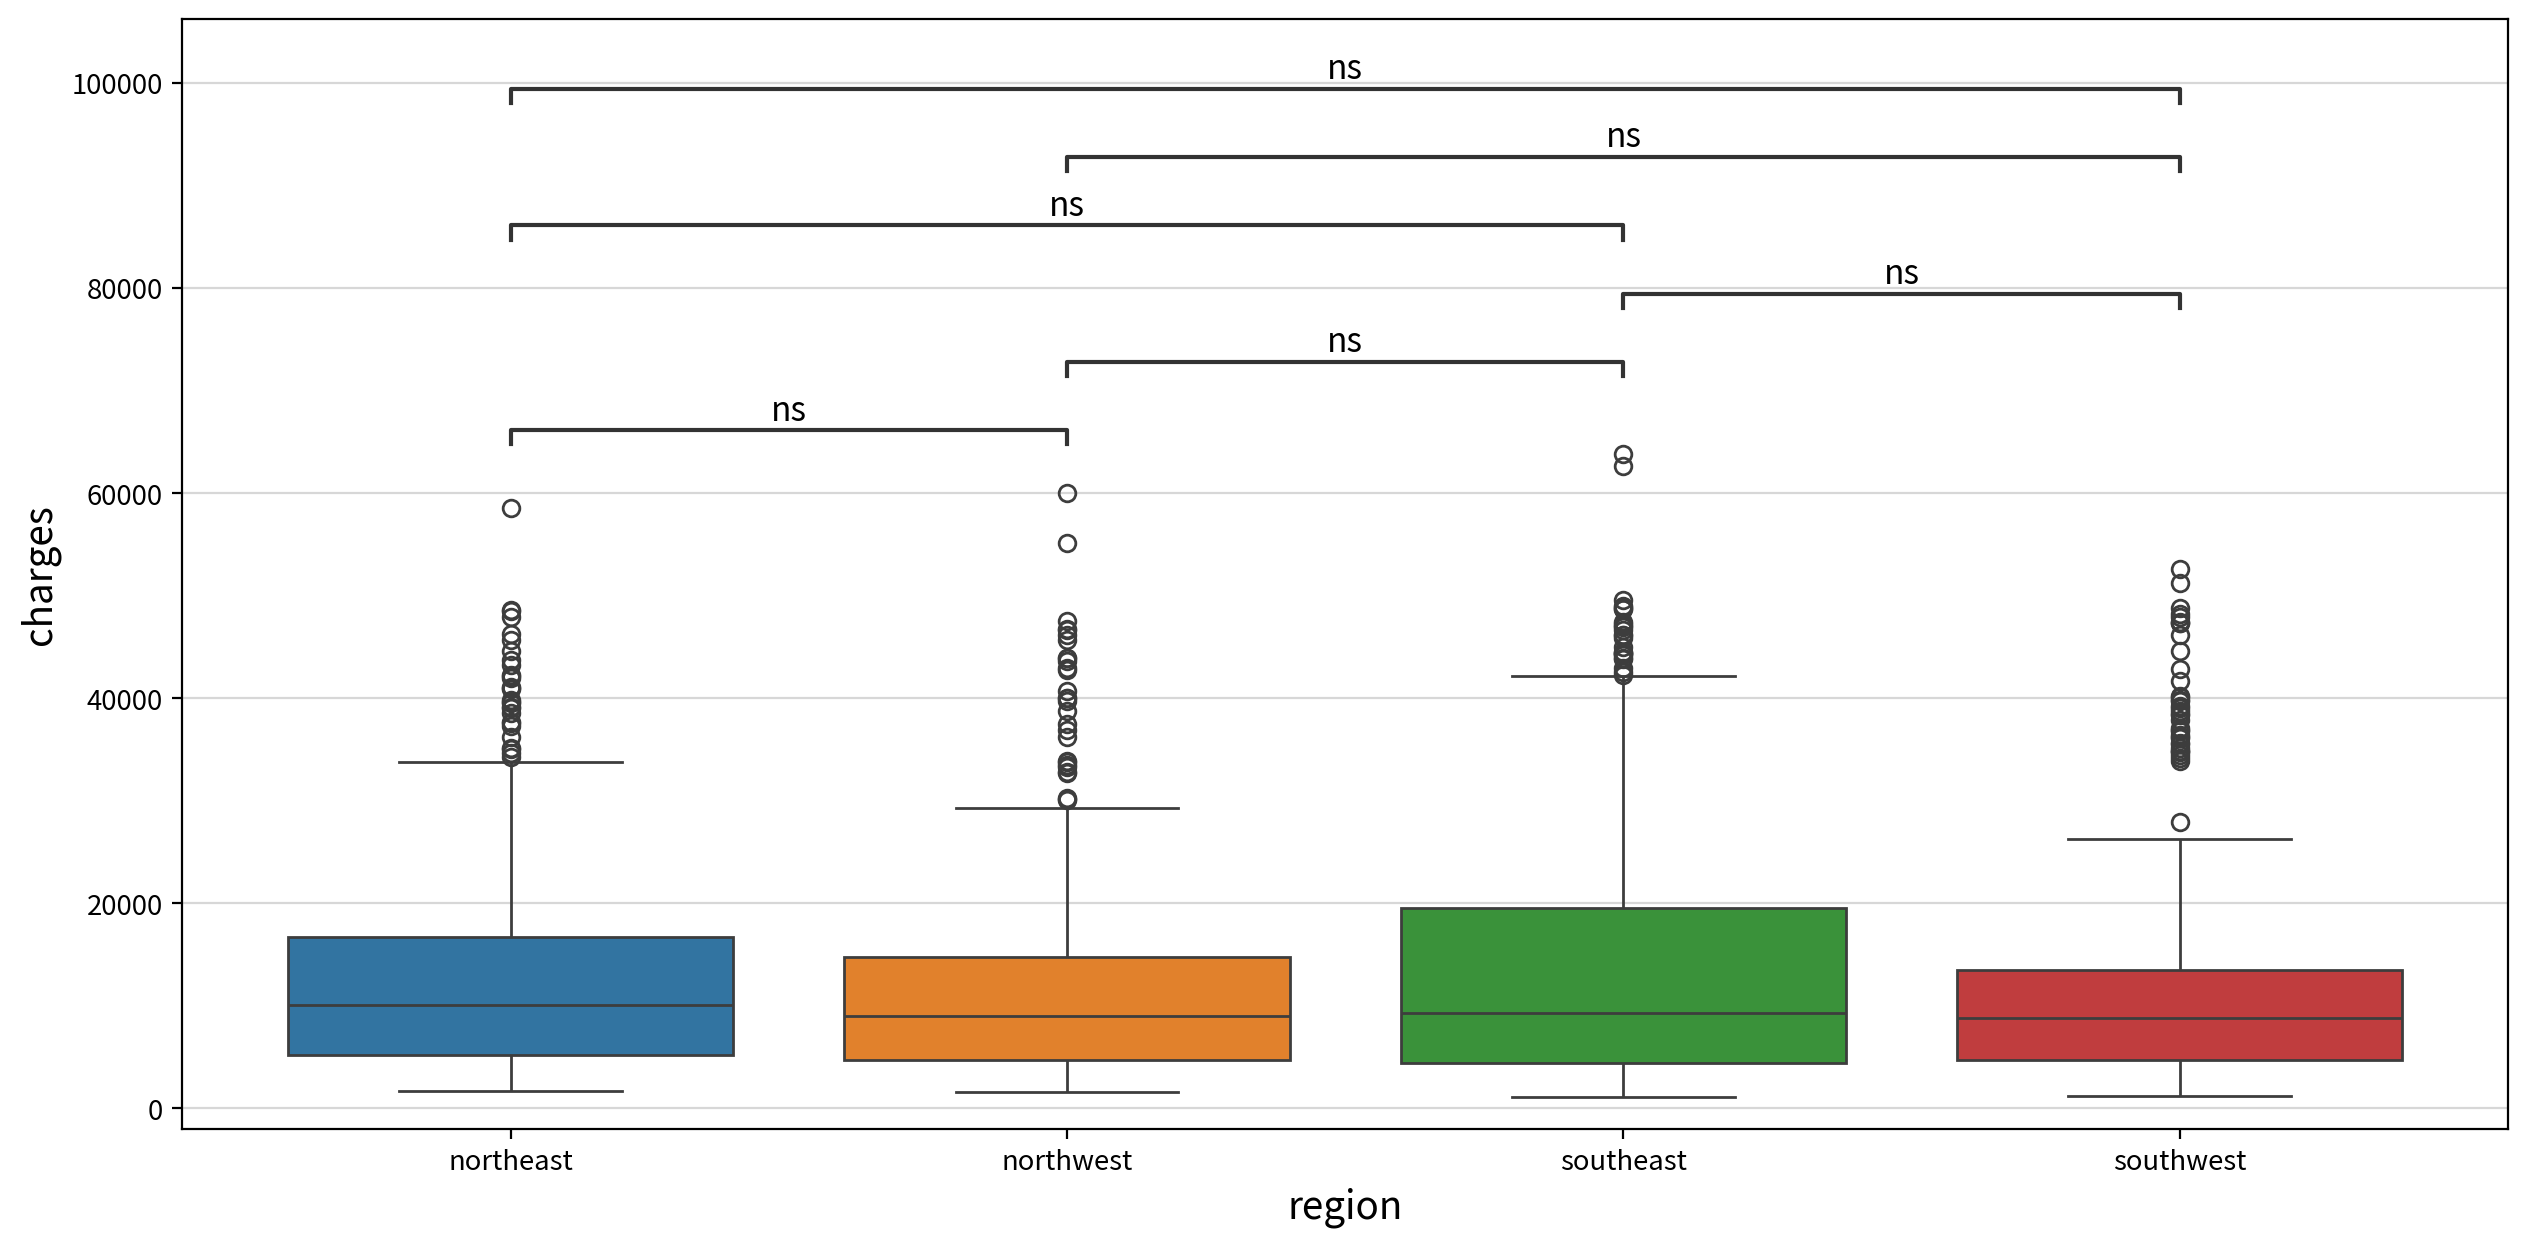

비교한 조합 쌍: 6개
유의한 쌍: 0개
평균 차이가 가장 큰 쌍: (southeast) vs (southwest) -> 차이 2388.474, 효과크기 Negligible, p-value 0.068
평균 차이가 가장 작은 쌍: (northwest) vs (southwest)-> 차이 103.903, 효과크기 Negligible, p-value 0.999


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,northeast,northwest,13406.385,12450.841,955.544,877.193,1.089,645.827,0.696,0.085,False,Negligible
1,Games-Howell,northeast,southeast,13406.385,14735.411,-1329.027,962.948,-1.380,679.413,0.512,-0.104,False,Negligible
2,Games-Howell,northeast,southwest,13406.385,12346.937,1059.447,895.549,1.183,646.648,0.638,0.093,False,Negligible
3,Games-Howell,northwest,southeast,12450.841,14735.411,-2284.571,956.389,-2.389,677.137,0.080,-0.180,False,Negligible
4,Games-Howell,northwest,southwest,12450.841,12346.937,103.903,888.492,0.117,645.983,0.999,0.009,False,Negligible
5,Games-Howell,southeast,southwest,14735.411,12346.937,2388.474,973.252,2.454,683.096,0.068,0.185,False,Negligible


In [48]:
for n in ['region']:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # anova 분석은 long 타입으로 바로 투입 가능
    display(my_stats.anova_oneway(origin, y=target, between=n))

    # 사후검정
    display(my_stats.posthoc_oneway(origin, y=target, between=n))

##### 결과 해석 (검정 결과표 기준)

**`region` → `charges` (명목 4집단)** — 집단 라벨 northeast, northwest, southeast, southwest

| 확인 항목 | 관찰 내용 |
|---|---|
| 적용된 검정 | 등분산 미충족으로 일반 ANOVA가 아니라 **Welch's ANOVA가 채택**됨 (F=2.566, ddof1=3, ddof2=740.416) |
| 주효과 | **p=0.053 ≥ 0.05** → 네 집단의 `charges` 평균에 유의한 차이가 없음 |
| 효과크기 | **np2=0.007 (Negligible)** |
| 사후검정 | **Games-Howell 6개 쌍 모두 `significant=False`** (최소 p=0.068, northwest–southeast p=0.080), hedges 값 모두 Negligible |
| 집단별 평균 | southeast 14735.411 > northeast 13406.385 > northwest 12450.841 > southwest 12346.937 |
| **채택 여부** | **제외** — 주효과·사후검정 모두 유의하지 않음 |

> 유의하지 않은 차이는 동등성의 증명이 아니다. 이변량 관계나 쌍별 상관만으로 다변량 관계 전체를 확정하지 않는다.


가장 큰 평균 차이는 southeast–southwest의 2,388.474달러, 가장 작은 차이는 northwest–southwest의 103.903달러였다. 후자의 Games–Howell p≈0.999이며, 평균 차이의 크기와 유의성을 구분해 읽는다. 자동 최소 차이 요약의 인덱스 오류를 정정하고 같은 데이터로 확인했다. 검정 결과표 자체는 바뀌지 않았다.

### 변수 채택 결과 표

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 가정점검 | 비대칭신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | smoker | Mann-Whitney U test | $< 0.05$ | 미제공 | 정규성 위배 → 비모수 검정 | 해당 없음 | 집단 간 차이 유의함 (no < yes) |
| ✅ 채택 | age | Spearman | $< 0.05$ | ρ=+0.533 (중간) | 정규성 위배 / 선형성 비기각 / 이상치 계수왜곡 있음 | 대칭 / 불필요 | 유의미한 상관 (\|coef\|≥0.3) |
| 🟡 후보 | children | Spearman | $< 0.05$ | ρ=+0.132 (약함) | 정규성 위배 / 선형성 위배 / 이상치 계수왜곡 없음 | 우편향 / 로그변환 후보(실제 변환은 전처리 표 확인) | 유의하나 관계 약함 (\|coef\|<0.3) → **모델링 투입 후 계수 유의성으로 최종 판정** |
| 🟡 후보 | bmi | Spearman | $< 0.05$ | ρ=+0.120 (약함) | 정규성 위배 / 선형성 비기각 / 이상치 계수왜곡 있음 | 대칭 / 불필요 | 유의하나 관계 약함 (\|coef\|<0.3) → **모델링 투입 후 계수 유의성으로 최종 판정** |
| ❌ 제외 | region | Welch's ANOVA | $0.053$ | np2=0.007 (Negligible) | 등분산 위배 → Welch 보정 | 해당 없음 | 주효과 유의하지 않음, Games-Howell 6쌍 전부 비유의 |
| ❌ 제외 | sex | Mann-Whitney U test | $0.695$ | 미제공 | 정규성 위배 → 비모수 검정 | 해당 없음 | 집단 간 차이 유의하지 않음 (집단 차이 비기각) |

> 유의하지 않은 차이는 동등성의 증명이 아니다. 이변량 관계나 쌍별 상관만으로 다변량 관계 전체를 확정하지 않는다.

<a id="multivariate"></a>

## 2-3. 다변량 분석

### 준비작업

### 앞 절의 분석 설정 재사용

동일 노트북 앞 절에서 불러온 데이터와 변수 유형 설정을 사용한다.

#### 2. 불러온 내용 확인

- 이전 분석 내역이 잘 로드 되었는지 확인한다.

In [49]:
print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형   :", continuous_cols)
print("명목형   :", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수 : charges
종속변수 유형: 연속형
연속형   : ['age', 'bmi', 'children']
명목형   : ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


#### 3. 라이브러리 참조

In [50]:
from IPython.display import display, Markdown

### 연속형 변수간의 다변량 분석

#### 1. 독립변수간 상관 분석

In [51]:
# 연속형 독립변수간의 상관분석
corr = my_stats.multi_correlation(origin,columns=continuous_cols, plot=False)

# 상관분석 결과 정리
my_stats.correlation_summary(corr)

,age,bmi,children
age,1.000,0.108,0.056
bmi,0.108,1.000,0.016
children,0.056,0.016,1.000


,max-y,max-coef,count,columns
x,,,,
age,bmi,0.108,0,-
bmi,age,0.108,0,-
children,age,0.056,0,-


#### 다중공선성 결과 해석

기존 독립변수 간 쌍별 상관에서 강한 중복 신호는 발견되지 않았다. 이 결과만으로 다변량 공선성이 없다고 확정하지 않고 뒤 VIF 결과를 함께 확인한다.

### 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 가정점검 | 비대칭신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | smoker | Mann-Whitney U test | $< 0.05$ | 미제공 | 정규성 위배 → 비모수 검정 | 해당 없음 | 집단 간 차이 유의함 (no < yes) |
| ✅ 채택 | age | Spearman | $< 0.05$ | ρ=+0.533 (중간) | 정규성 위배 / 선형성 비기각 / 이상치 계수왜곡 있음 | 대칭 / 불필요 | 유의미한 상관 (\|coef\|≥0.3) |
| 🟡 후보 | children | Spearman | $< 0.05$ | ρ=+0.132 (약함) | 정규성 위배 / 선형성 위배 / 이상치 계수왜곡 없음 | 우편향 / 로그변환 후보(실제 변환은 전처리 표 확인) | 유의하나 관계 약함 (\|coef\|<0.3) → **모델링 투입 후 계수 유의성으로 최종 판정** |
| 🟡 후보 | bmi | Spearman | $< 0.05$ | ρ=+0.120 (약함) | 정규성 위배 / 선형성 비기각 / 이상치 계수왜곡 있음 | 대칭 / 불필요 | 유의하나 관계 약함 (\|coef\|<0.3) → **모델링 투입 후 계수 유의성으로 최종 판정** |
| ❌ 제외 | region | Welch's ANOVA | $0.053$ | np2=0.007 (Negligible) | 등분산 위배 → Welch 보정 | 해당 없음 | 주효과 유의하지 않음, Games-Howell 6쌍 전부 비유의 |
| ❌ 제외 | sex | Mann-Whitney U test | $0.695$ | 미제공 | 정규성 위배 → 비모수 검정 | 해당 없음 | 집단 간 차이 유의하지 않음 (집단 차이 비기각) |

> 유의하지 않은 차이는 동등성의 증명이 아니다. 이변량 관계나 쌍별 상관만으로 다변량 관계 전체를 확정하지 않는다.

<a id="preprocessing"></a>

## 3. 분석용 데이터 전처리

### 준비작업

#### 라이브러리 참조

In [52]:
from jussam import load_data
from helpers import *

#### 전처리 대상 데이터

품질 점검 데이터와 요약표를 다시 불러온다. 원본의 EDA 변수 선택을 반영해 sex·region을 제외하고 age·bmi·children·smoker를 사용한다. 제외는 이 분석의 선택 규칙이며 두 변수의 무관함을 입증한 것은 아니다.

In [53]:
origin = load_data("insurance_qtcheck")
desc = load_data("insurance_qtcheck_desc")
cat_desc = load_data("insurance_qtcheck_category_desc")

# 명목형 기술통계량 표의 컬럼명이 곧 명목형 변수 목록이다
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

📚 보험 비용 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)
📚 보험 비용 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 보험 비용 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


##### 변수 유형 분류와 EDA 결과 반영

In [54]:
target = "charges"

nominal_cols = my_qtcheck.get_categorical_column_names(df)
continuous_cols = my_qtcheck.get_number_column_names(df)
continuous_cols.remove(target)

print("[EDA 반영 전] 명목형 :", nominal_cols)

# EDA에서 채택되지 않은 변수를 걷어낸다
df = df.drop(columns=['sex', 'region'])
cat_desc = cat_desc.drop(columns=['sex', 'region'])
nominal_cols = cat_desc.columns.to_list()

print("[EDA 반영 후] 명목형 :", nominal_cols)
print("           연속형 :", continuous_cols)
print("           크기   :", df.shape)

[EDA 반영 전] 명목형 : ['sex', 'smoker', 'region']
[EDA 반영 후] 명목형 : ['smoker']
           연속형 : ['age', 'bmi', 'children']
           크기   : (1337, 5)


##### 명목형 라벨링

In [55]:
df1 = my_prep.labeling(df, columns=nominal_cols)
df1.head()

smoker (2종): no=0,yes=1


,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.924
1,18,33.770,1,0,1725.552
2,28,33.000,3,0,4449.462
3,33,22.705,0,0,21984.471
4,32,28.880,0,0,3866.855


##### 더미변수 인코딩

In [56]:
df2 = my_prep.dummies(df1, columns=nominal_cols, drop_first=True)
df2.head()

smoker (2종) -> 생략: 이진 변수이므로 원래 컬럼을 유지

컬럼 수: 5개 -> 5개


,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.924
1,18,33.770,1,0,1725.552
2,28,33.000,3,0,4449.462
3,33,22.705,0,0,21984.471
4,32,28.880,0,0,3866.855


##### 로그 변환 대상 선정

In [57]:
# 기술통계량 표가 왜도·첨도·최솟값을 근거로 변환 종류를 미리 판정해 둔다
log_cols = desc.loc[desc['log_need'] == 'log'].index.tolist()
log1p_cols = desc.loc[desc['log_need'] == 'log1p'].index.tolist()
reflect_cols = desc.loc[desc['log_need'] == 'reverse_log1p'].index.tolist()

print("순수 log  :", log_cols)
print("log(1+x)  :", log1p_cols)
print("반사 후 log:", reflect_cols)

desc[['skew', 'kurt', 'min', 'log_need']]

순수 log  : ['charges']
log(1+x)  : ['children']
반사 후 log: []


,skew,kurt,min,log_need
age,0.055,-1.244,18.000,none
bmi,0.284,-0.053,15.960,none
children,0.937,0.201,0.000,log1p
charges,1.515,1.604,1121.874,log


##### 로그 변환

In [58]:
df3 = my_prep.log_transform(df2, log_columns=log_cols,
                            log1p_columns=log1p_cols,
                            reflect_columns=reflect_cols)

컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
charges   우측 꼬리     log(x)                exp(y)                   1.51 -> -0.09
children  우측 꼬리     log(1+x)              exp(y)-1                  0.94 -> 0.26


##### 이상치 대체

In [59]:
df4 = my_prep.replace_outlier(df3, columns=continuous_cols)

이상치 대체 방식: 'bound' (기준: IQR x 1.5)
컬럼                               정상 범위       이상치                   대체값
- * 68
age                    -9.00 ~ 87.00    0개(0.0%)      -9.00 또는 87.00
bmi                    13.67 ~ 47.32    9개(0.7%)      13.67 또는 47.32
children                -1.65 ~ 2.75    0개(0.0%)       -1.65 또는 2.75


##### 다중공선성 제거

In [60]:
df5 = my_prep.reduce_vif(df4, columns=continuous_cols, threshold=10.0)


완료! 남은 변수: ['age', 'bmi', 'children']
최대 VIF = 1.01


##### 정규화

In [61]:
df6 = my_prep.scaling(df5, columns=continuous_cols, method='standard')

df6.describe().T[['mean', 'std', 'min', 'max']]

StandardScaler 적용 (3개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
age                18.00 ~ 64.00          -1.51 ~ 1.76
bmi                15.96 ~ 47.32          -2.43 ~ 2.75
children             0.00 ~ 1.79          -1.04 ~ 2.17


,mean,std,min,max
age,-0.000,1.000,-1.512,1.765
bmi,-0.000,1.000,-2.425,2.751
children,-0.000,1.000,-1.043,2.167
smoker,0.205,0.404,0.000,1.000
charges,9.100,0.919,7.023,11.063


#### 전처리 결과와 모델 비교의 연결

sex·region을 제외한 뒤 age·bmi·children·smoker와 종속변수 charges의 5개 열이 남았다. smoker는 no=0, yes=1로 라벨링됐으며 이진 변수여서 별도의 더미 열은 추가되지 않았다.

charges에는 log, children에는 log1p를 적용해 왜도가 각각 약 1.51→−0.09, 0.94→0.26으로 완화됐다. 연속형 독립변수의 IQR 경계값 대체는 bmi의 9개 값에만 적용됐으며 행은 삭제되지 않았다. VIF는 최대 약 1.01로 제거된 변수가 없었다. 표준화 대상은 age·bmi·children이며 smoker와 로그 척도의 charges는 표준화하지 않았다.

전처리 결과가 항상 원래 금액 단위 성능을 개선하는지는 아래 비교에서 판단한다. 모델 비교는 이 메모리상의 df를 자동 연결하지 않고 원본대로 패키지 checkpoint_0~4를 다시 읽는다. 품질 점검에서 저장한 엑셀과 모델링 입력을 같은 파일이라고 간주하지 않는다.

<a id="modeling"></a>

## 4. 회귀모형 비교·해석·진단

### 준비작업

#### 라이브러리 참조

In [62]:
from jussam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame

# 성능 평가 지표 (직접 계산하지 않고 sklearn 의 함수를 사용한다)
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

#### 다섯 체크포인트의 비교

라벨링·더미 인코딩 기준선에 로그변환 → 이상치 대체 → VIF → 표준화를 누적한 패키지 체크포인트를 불러온다. 각 모형을 후진소거로 적합하고 원본 금액 단위의 RMSE를 우선 비교한다. 전처리가 많다는 이유로 최종 모형을 선택하지 않는다.

In [63]:
df0 = load_data("insurance_checkpoint_0")
df1 = load_data("insurance_checkpoint_1")
df2 = load_data("insurance_checkpoint_2")
df3 = load_data("insurance_checkpoint_3")
df4 = load_data("insurance_checkpoint_4")

df0.head()

📚 보험 비용 데이터셋의 전처리 체크포인트 0 - 기준선 역할을 위해 라벨링과 더미변수 처리만 적용됨
📚 보험 비용 데이터셋의 전처리 체크포인트 1 - 라벨링 + 더미변수 + 로그변환
📚 보험 비용 데이터셋의 전처리 체크포인트 2 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체
📚 보험 비용 데이터셋의 전처리 체크포인트 3 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거
📚 보험 비용 데이터셋의 전처리 체크포인트 4 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거 + 스케일링


,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.924
1,18,33.770,1,0,1725.552
2,28,33.000,3,0,4449.462
3,33,22.705,0,0,21984.471
4,32,28.880,0,0,3866.855


##### 분석 대상 정리

In [64]:
# 종속변수
target = "charges"

# 비교 대상 체크포인트 (아래로 갈수록 전처리가 하나씩 누적된다)
checkpoints = { "0_기준선": df0, "1_로그변환": df1, "2_이상치대체": df2,
    "3_공선성제거": df3, "4_스케일링": df4 }

# 종속변수(charges)에 순수 log 변환이 적용되었는지 여부 (체크포인트 1부터 적용됨)
log_y = { "0_기준선": False, "1_로그변환": True, "2_이상치대체": True,
    "3_공선성제거": True, "4_스케일링": True }

# log1p 가 적용된 독립변수 (기준선은 없고, 체크포인트 1부터 children 에 적용됨)
log1p_x = { "0_기준선": [], "1_로그변환": ["children"], "2_이상치대체": ["children"],
    "3_공선성제거": ["children"], "4_스케일링": ["children"] }

##### 의료보험 청구비용의 척도 확인

In [65]:
charges_scale = DataFrame()

for name in checkpoints:
    data = checkpoints[name]
    charges_scale[name] = data[target].describe()

charges_scale.round(3)

,0_기준선,1_로그변환,2_이상치대체,3_공선성제거,4_스케일링
count,1337.000,1337.000,1337.000,1337.000,1337.000
mean,13279.121,9.100,9.100,9.100,9.100
std,12110.360,0.919,0.919,0.919,0.919
min,1121.874,7.023,7.023,7.023,7.023
25%,4746.344,8.465,8.465,8.465,8.465
50%,9386.161,9.147,9.147,9.147,9.147
75%,16657.717,9.721,9.721,9.721,9.721
max,63770.428,11.063,11.063,11.063,11.063


##### 체크포인트별 모형 적합 및 성능 비교

In [66]:
fits = {}
result = []

for c in checkpoints:
    data = checkpoints[c]       # 체크포인트 데이터프레임
    log = log_y[c]              # 종속변수에 순수 log 가 적용되었는지 여부

    # --- 1) 모형 적합 (유의하지 않은 변수는 후진소거로 제거) ---
    fit = my_ols.auto_ols(data, target,
                log_y=log, log1p_x=log1p_x[c],
                backward=True, report=False, test=False)

    fits[c] = fit

    # --- 2) 실제값과 예측값을 원본 척도(달러)로 되돌린다 ---
    if log:
        # 종속변수는 순수 log 변환이므로 역변환은 exp 를 사용한다 (log1p 면 expm1)
        y_true = np.exp(data[target])
        y_pred = np.exp(fit.fittedvalues)
    else:
        y_true = data[target]       # 체크포인트 0 은 이미 원본 척도
        y_pred = fit.fittedvalues

    # --- 3) 지표를 한 행으로 정리해 저장 ---
    result.append({
        "모델": c,
        "변수수": int(fit.df_model),        # 상수항을 제외한 독립변수 개수
        "R2(모델척도)": fit.rsquared,       # 척도가 다르면 비교 불가 (참고용)
        "Adj.R2": fit.rsquared_adj,
        "AIC": fit.aic,
        # 아래 세 지표는 원본 척도(달러)에서 계산하므로 체크포인트간 비교가 가능하다
        "R2(원본척도)": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    })

rdf = DataFrame(result).set_index("모델")
rdf.round(3)

,변수수,R2(모델척도),Adj.R2,AIC,R2(원본척도),RMSE,MAE
모델,,,,,,,
0_기준선,4,0.750,0.749,27092.752,0.750,6058.642,4181.335
1_로그변환,4,0.763,0.762,1653.311,0.532,8281.268,4247.790
2_이상치대체,4,0.763,0.762,1652.808,0.532,8278.466,4248.574
3_공선성제거,4,0.763,0.762,1652.808,0.532,8278.466,4248.574
4_스케일링,4,0.763,0.762,1652.808,0.532,8278.466,4248.574


##### 최종 모형의 회귀계수와 영향력 순위

In [67]:
final_name = "0_기준선"

final_fit = fits[final_name]
final_data = checkpoints[final_name]

print(f"최종 모형: {final_name} | 등분산 위배(HC3 사용) = {final_fit.use_hc3_}")

my_ols.report_variables(final_fit, final_data, hc3=final_fit.use_hc3_)

최종 모형: 0_기준선 | 등분산 위배(HC3 사용) = True


,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,charges,smoker,23810.399,411.414,573.837,0.794,57.875,41.493,0.000,0.000,0.999,1.001
1,charges,age,257.773,11.910,11.877,0.299,21.644,21.704,0.000,0.000,0.986,1.014
2,charges,bmi,321.871,27.388,30.077,0.162,11.752,10.702,0.000,0.000,0.988,1.012
3,charges,children,472.975,137.879,131.271,0.047,3.430,3.603,0.001,0.000,0.998,1.002


##### 최종 모형의 회귀분석 가정 검정

In [68]:
my_ols.test_linear(final_fit, plot=False)       # 1) 선형성
my_ols.test_normal(final_fit, plot=False)      # 2) 정규성
my_ols.test_equalvar(final_fit)                # 3) 등분산성
my_ols.test_independent(final_fit)             # 4) 독립성

,statistic,p-value,linearity,result
Ramsey RESET,141.672,0.000,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.163,0.000,False,대립가설 채택 → 정규성 위배


,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,65~71,73.000,위배
±2√MSE,95.000,94~96,94.690,충족
±3√MSE,99.700,99~100,97.980,위배


√MSE = 6070.00 · 구간 규칙 판정: 정규성 위배


,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,116.980,0.000,31.929,0.000,False,대립가설 채택 → 등분산 아님


,statistic,independence,result
Durbin-Watson,2.088,True,독립성 만족


## 종합 결과 해석

### 1. 어떤 데이터이며 비용 분포는 어떠했는가

완전 중복 1행을 제거한 1,337행에는 결측치가 없었다. 청구비용의 평균은 약 13,279달러이고 중앙값은 약 9,386달러로, 평균이 중앙값보다 높았다. 왜도 1.515와 상단 IQR 이상치 139개(약 10.4%)는 일부 고액 관측치가 오른쪽 꼬리를 형성한다는 사실과 일치한다. 따라서 대표적인 비용 수준을 설명할 때 평균 하나만 제시하기보다 중앙값과 분포를 함께 보는 것이 적절하다.

고액 관측치라는 사실은 입력 오류라는 뜻이 아니다. 이 분석은 원본 절차를 따라 연속형 독립변수의 IQR 경계값 대체를 비교했으며, 청구비용의 상단 139개를 삭제하거나 잘라내지는 않았다. 최종 채택된 기준선에는 그 독립변수 대체도 적용되지 않았다.

### 2. EDA에서 무엇을 발견했고 회귀에서는 어떻게 달라졌는가

age와 charges의 Spearman 상관은 0.533으로 양의 관계였고, bmi와 children은 각각 0.120, 0.132로 약한 양의 관계였다. 흡연자와 비흡연자의 분포 차이는 유의했지만 성별은 p≈0.695로 유의한 차이를 발견하지 못했다. 지역 비교 역시 Welch ANOVA p≈0.053, Games–Howell 6쌍 모두 비유의였다. 이 결과에 따라 sex·region을 제외하는 분석 절차를 유지했다. 다만 비유의성은 집단의 동등성이나 모든 조건에서의 무관함을 입증하지 않는다.

BMI와 자녀 수는 단독 상관이 약했어도 다른 포함 변수를 함께 고려한 최종 회귀에서 유의했다. 단독 상관은 두 변수만의 순위 관계이며, 회귀계수는 다른 변수를 고정한 조건부 관계다. 두 결과는 질문이 다르므로 모순이라고 볼 수 없다. 통계적 유의성과 관계의 크기도 별도로 해석해야 한다.

### 3. 왜 전처리가 가장 적은 기준선을 선택했는가

| 체크포인트 | 변수 수 | 모델 척도 R² | 원본 척도 R² | RMSE(달러) | MAE(달러) |
|---|---:|---:|---:|---:|---:|
| 기준선 | 4 | 0.750 | 0.750 | 6,058.642 | 4,181.335 |
| 로그변환 | 4 | 0.763 | 0.532 | 8,281.268 | 4,247.790 |
| 이상치 대체 | 4 | 0.763 | 0.532 | 8,278.466 | 4,248.574 |
| VIF 점검 | 4 | 0.763 | 0.532 | 8,278.466 | 4,248.574 |
| 표준화 | 4 | 0.763 | 0.532 | 8,278.466 | 4,248.574 |

log(charges)의 왜도는 약 −0.09로 완화됐고 모델 척도 R²도 높아졌다. 그러나 원래 달러 단위로 되돌린 RMSE·MAE는 기준선보다 나빴다. 따라서 **분포가 대칭에 가까워지는 것과 원본 금액을 더 잘 맞추는 것은 같은 목표가 아니다.** 모델 척도 R²나 종속변수 척도가 다른 AIC 수치만으로 로그 모형이 우수하다고 판단하지 않았다.

기준선은 다섯 모형 중 원본 척도 RMSE와 MAE가 모두 가장 작고 변수 수는 동일하므로 선택 근거가 명확하다. VIF 단계에서는 제거된 변수가 없었으며, 상수항을 포함한 같은 OLS 모형에서 독립변수의 표준화는 계수 단위를 바꾸지만 적합값은 바꾸지 않았다. 그래서 뒤 세 모형의 지표가 같게 나타난 것을 계산 누락으로 해석하지 않는다.

로그 모형의 예측값은 exp로 단순 역변환했으며 별도 재변환 편향 보정은 하지 않았다. 비교 결론은 이 절차 안에서의 결과다. 고액 구간이 오차에 얼마나 기여했는지에 대한 별도 분석은 수행하지 않았으므로 특정 구간을 성능 악화의 확정 원인으로 단정하지 않는다.

### 4. 최종 회귀계수를 어떻게 읽어야 하는가

아래는 **다른 포함 변수를 고정했을 때**의 모형상 청구비용 차이다. 금액 단위는 달러다.

| 변수 | 계수 B | 표준화 계수 β | 조건부 해석 |
|---|---:|---:|---|
| smoker | 23,810.399 | 0.794 | 흡연자(1)는 비흡연자(0)보다 약 23,810달러 높은 예측 비용 |
| age | 257.773 | 0.299 | 나이 1세 증가와 약 257.77달러 높은 예측 비용이 관련 |
| bmi | 321.871 | 0.162 | BMI 1단위 증가와 약 321.87달러 높은 예측 비용이 관련 |
| children | 472.975 | 0.047 | 부양 자녀 수 1명 증가와 약 472.98달러 높은 예측 비용이 관련 |

네 변수 모두 HC3 기준 p<0.05였다. 표준화 계수의 절댓값은 smoker가 가장 크고 age·bmi·children 순이었다. 이는 이 표본과 모형에서의 비교이지 “흡연이 나이보다 몇 배 중요하다”는 보편적 중요도 순위는 아니다. 특히 이진 변수와 연속형 변수의 표준화 계수는 표본의 분산·범주 비율에도 영향을 받는다.

흡연자와 비흡연자의 회귀상 차이를 금연의 효과, 개인별 실제 비용 변화, 보험료 할증액으로 바꾸어 읽지 않는다. 데이터의 charges는 청구비용이며 납입 보험료가 아니고, 이 관찰자료는 인과효과를 식별하도록 설계되지 않았다.

### 5. 진단 결과가 결론에 부과하는 한계

Ramsey RESET 통계량 141.672, 잔차 정규성 검정 통계량 0.163, Breusch–Pagan F=31.929에서 각각 p<0.001이 출력됐다. 사용한 진단 기준에서 함수 형태·잔차 정규성·등분산성에 문제가 있다는 신호다. RESET 기각만으로 특정 곡선 관계나 누락 변수 하나를 확정할 수는 없다.

계수의 유의성은 HC3 표준오차로 보고했지만, HC3는 비선형성이나 이분산 자체를 없애지 않는다. DW=2.088은 자동 표에서 ‘독립성 만족’으로 표시되지만, 임의 순서의 횡단면 자료에서 이 값만으로 독립성을 입증하지 않는다. R²=0.750도 비용 변동의 약 75%를 표본 안에서 설명했다는 뜻이지 75%의 예측이 정답이라는 뜻이 아니다.

### 6. 결론과 회고

이 분석의 결론은 **흡연 여부·나이·BMI·자녀 수와 청구비용의 조건부 관계를 확인했고, 비교한 다섯 절차 중 기준선이 원본 금액 단위의 표본 내 오차에서 가장 유리했다**는 것이다. 새 고객의 비용을 충분히 정확하게 예측하거나 요율표로 사용할 수 있다는 결론까지 확장하지 않는다.

모든 변수 선택과 성능 비교를 같은 표본에서 수행했다. 향후 실무 적용을 판단하려면 독립적인 검증자료, 비용 구간별 오차, 함수 형태의 적합성 등을 별도로 확인해야 한다. 이는 이번 결과의 한계와 후속 검증 과제이며, 현재 노트북에 새로운 분석 방법을 추가한 것은 아니다. 전처리는 많이 하는 것이 목표가 아니라 분석 목적에 맞는 지표와 해석 가능성을 개선하는 수단이라는 점을 확인했다.

## 검증 및 재실행 안내

68개 코드 셀의 실행 번호가 1~68로 이어지고 오류 출력은 없었다. pandas observed 기본값 변경 관련 FutureWarning은 남아 있으나 실행을 중단시키지 않았다. 회귀 비교표와 계수·가정 검정 결과를 본문 및 README와 대조했다.

지역 사후검정의 ‘평균 차이가 가장 작은 쌍’ 자동 요약은 idxmin으로 수정해 같은 데이터로 다시 확인했다. 검정 수치·그래프·분석 코드·기존 실행 번호는 유지했다. 이번 보완 내용을 읽기 위해 전체 분석을 다시 실행할 필요는 없다. 추후 재실행할 때는 커널을 재시작해 수정된 로컬 helpers를 불러온다.